<a href="https://colab.research.google.com/github/liliettemorejon/ML-for-NLP/blob/main/MNIST_Final_Group4_FULL_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Form ML-7 Mileage Log Reader — ISM 6642, Group 4 (full version for Google Colab)

Reads handwritten Sabal Coast Home Health mileage logs (Form ML-7) from a phone photo, checks every row
against the form's rules, and decides **row by row** what can be auto-posted and what goes to a clerk.
This is the **full** notebook: it downloads EMNIST, trains the two models, tests them on synthetic logs, reads the
four real forms and lets you upload new photos. (The short demo notebook skips everything up to the photos.)

**How to run:** Runtime > Change runtime type > **T4 GPU** (training is much faster), then **Runtime > Run all**.
Set `RETRAIN = False` in the settings cell to skip training and use the weights already in the GitHub repo.

| Step | `RETRAIN = True` (default) | `RETRAIN = False` |
| --- | --- | --- |
| Clone the GitHub repo (blank form, box layout, HR data, photos, weights) | seconds | seconds |
| Download EMNIST (~560 MB) | a minute or two, every new Colab session | same |
| Train the baseline and augmented models (5 epochs each) | several minutes each on a T4 | skipped (weights come from the repo) |
| Synthetic logs + evaluation | about a minute | same |
| The four real forms + summary | seconds | same |
| Upload your own photos (last section) | seconds per photo | same |

Colab erases its files when the session ends, so trained weights do not survive. The last cell downloads them.

## Setup: libraries and the GitHub repo

In [ ]:
%pip install -q pillow-heif

# Standard library
import os, sys, json, glob, gzip, re, math, zipfile, shutil, subprocess, time, urllib.request
import datetime as dt
from pathlib import Path

# Data, images and plots
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from scipy import ndimage
from PIL import Image, ImageOps
from pillow_heif import register_heif_opener      # iPhone HEIC photos
from google.colab import files                    # photo upload (last section)

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

register_heif_opener()

# ---- The GitHub repo with assets/, models/ and samples/ ----
REPO_URL = 'https://github.com/liliettemorejon/ML-for-NLP.git'
# (private repo? use 'https://<TOKEN>@github.com/USER/REPO.git' with a token from Colab Secrets)
ROOT = Path('/content') / Path(REPO_URL).stem        # the project folder

if not ROOT.exists():
    subprocess.run(['git', 'clone', '--depth', '1', REPO_URL, str(ROOT)], check=True)
else:
    subprocess.run(['git', '-C', str(ROOT), 'pull', '-q'], check=True)

missing = [p for p in ('assets/blank_form_ML7.png', 'assets/form_layout.json', 'assets/reference_data.json')
           if not (ROOT / p).exists()]
assert not missing, f'Missing from the repo: {missing}'
print('Repo OK:', ROOT)
print('Sample photos in the repo:', sorted(p.name for p in (ROOT / 'samples').glob('ODO_*')) or 'none')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 42.2 MB/s eta 0:00:00
Repo OK: /content/ML-for-NLP
Sample photos in the repo: none


## Constants and settings

In [ ]:
# ---- Folders ----
# (ROOT is the cloned GitHub repo, set in the setup cell)
DATA = ROOT / 'data'
EMNIST_DIR = DATA / 'emnist'
SYNTH_DIR = DATA / 'synthetic_logs'
ASSETS = ROOT / 'assets'                       # blank form, box layout, made-up HR data
MODELS = ROOT / 'models'
SAVE_PATH = MODELS / 'char_cnn_best.pt'        # baseline model
AUG_PATH = MODELS / 'char_cnn_aug_best.pt'     # augmented model (also used by demo.py)
UPLOAD_DIR = ROOT / 'samples' / 'uploads'         # photos you upload in Section 7
for d in (EMNIST_DIR, SYNTH_DIR, MODELS, UPLOAD_DIR):
    d.mkdir(parents=True, exist_ok=True)
EMNIST_URL = 'https://biometrics.nist.gov/cs_links/EMNIST/gzip.zip'

# ---- Characters ----
EMNIST_MAP = "0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz"
N_CLASSES = 36                     # 0-9 and A-Z (lowercase dropped: the form only allows capitals)
DIGITS = list(range(10))
LETTERS_IDX = list(range(10, 36))

# ---- Training ----
RETRAIN = True         # True = train both models here; False = use the weights already in the repo (models/)
VAL_FRACTION = 0.1     # share of the EMNIST train split kept for validation
SPLIT_SEED = 42
BATCH_SIZE = 128
EVAL_BATCH_SIZE = 256
LEARNING_RATE = 0.001
EPOCHS = 5

# ---- Synthetic test logs ----
SYNTH_SEED = 2026
BOX = 62                                   # box size on the form, in pixels
CONDITIONS = {'clean': (0.1, 0.0),         # condition: (messy handwriting, photo degradation strength)
              'phone': (0.5, 0.6),
              'rough': (0.75, 1.0)}
N_PER_CONDITION = 20
AS_OF_SYNTH = dt.date(2026, 10, 31)        # synthetic week-endings run up to 10/25/26, so "today" is set after that

# ---- Business rules ----
CONF_MIN = 0.50          # any character below this confidence -> human review
MAX_TRIP_MILES = 300     # longer trips are flagged as implausible
MAX_AGE_DAYS = 60        # week ending must be a Sunday within the last 60 days

# ---- Rule-guided auto-correct (Section 6) ----
AUTO_CORRECT = True                                       # False = never change a read, only flag it
AUTO_CORRECT_FIELDS = ('odo_start', 'odo_end', 'miles')   # only mileage numbers (dates and clients are never changed)
ALT_MIN_PROB = 0.05                                       # a runner-up guess needs at least this probability to be tried
CONFIRM_LOW_CONF = True                                   # an unsure mileage digit is accepted if end - start = miles agrees

# ---- Form fields per row ----
KEYS = ['date', 'client', 'odo_start', 'odo_end', 'miles']

# ---- Same random start every run ----
SEED = 0
torch.manual_seed(SEED); np.random.seed(SEED)

# ---- Device: GPU for training if there is one; reading the forms runs on the CPU (same as demo.py) ----
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')          # Apple Silicon GPU
else:
    device = torch.device('cpu')
cpu = torch.device('cpu')
print('Project folder:', ROOT)
print('Training on:', device)

Project folder: /content/ML-for-NLP
Training on: cuda


## 1. Data: EMNIST ByClass, digits and capital letters

In [ ]:
needed = [f'emnist-byclass-{s}-{k}' for s in ('train', 'test') for k in ('images-idx3-ubyte.gz', 'labels-idx1-ubyte.gz')]

if not all((EMNIST_DIR / n).exists() for n in needed):
    zip_path = DATA / 'emnist_gzip.zip'
    if not zip_path.exists():
        print('Downloading EMNIST (~560 MB, first run only) ...')
        if shutil.which('curl'):       # curl uses the system certificates (python.org Python on macOS has none)
            subprocess.run(['curl', '-L', '--fail', '-s', '-o', str(zip_path), EMNIST_URL], check=True)
        else:
            urllib.request.urlretrieve(EMNIST_URL, zip_path)
    with zipfile.ZipFile(zip_path) as z:
        for n in needed:
            (EMNIST_DIR / n).write_bytes(z.read(f'gzip/{n}'))
    zip_path.unlink()
print(sorted(p.name for p in EMNIST_DIR.iterdir()))

['emnist-byclass-test-images-idx3-ubyte.gz', 'emnist-byclass-test-labels-idx1-ubyte.gz', 'emnist-byclass-train-images-idx3-ubyte.gz', 'emnist-byclass-train-labels-idx1-ubyte.gz']


In [ ]:
def load_idx_images(path):
    with gzip.open(path, 'rb') as f:
        data = f.read()
    magic, n, rows, cols = np.frombuffer(data[:16], dtype='>i4')
    assert magic == 2051, f"Not an idx image file: {path}"
    return np.frombuffer(data, dtype=np.uint8, offset=16).reshape(n, rows, cols)

def load_idx_labels(path):
    with gzip.open(path, 'rb') as f:
        data = f.read()
    magic, n = np.frombuffer(data[:8], dtype='>i4')
    assert magic == 2049, f"Not an idx label file: {path}"
    return np.frombuffer(data, dtype=np.uint8, offset=8)

def load_emnist(split):
    x = load_idx_images(EMNIST_DIR / f'emnist-byclass-{split}-images-idx3-ubyte.gz')
    y = load_idx_labels(EMNIST_DIR / f'emnist-byclass-{split}-labels-idx1-ubyte.gz')
    x = np.ascontiguousarray(x.transpose(0, 2, 1))  # EMNIST is stored transposed
    return x, y

x_train_all, y_train_all = load_emnist('train')
x_test_all,  y_test_all  = load_emnist('test')
print(x_train_all.shape, x_test_all.shape)

(697932, 28, 28) (116323, 28, 28)


Orientation OK: average '1' is 22 tall x 12 wide


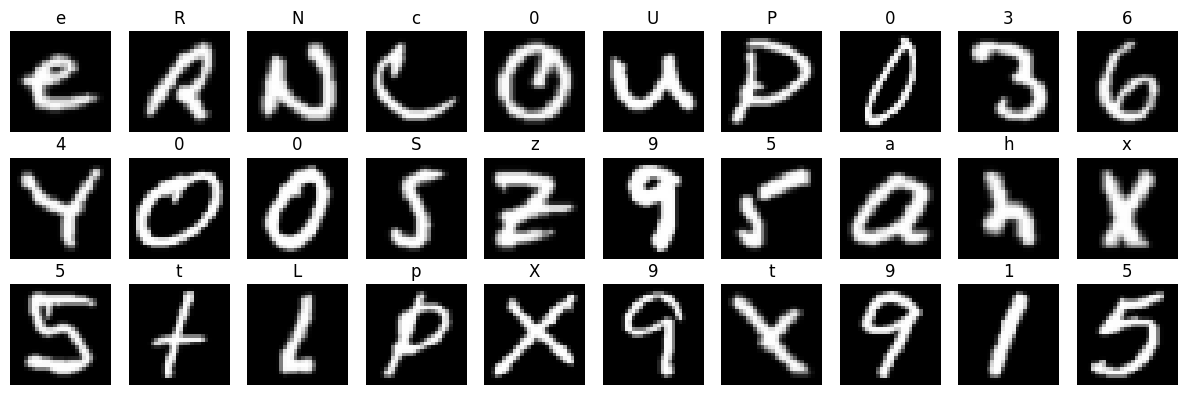

In [ ]:
def ink_extent(img, thr=60):
    rows = np.where(img.max(axis=1) > thr)[0]
    cols = np.where(img.max(axis=0) > thr)[0]
    return np.ptp(rows) + 1, np.ptp(cols) + 1   # height, width

mean_one = x_train_all[y_train_all == 1][:2000].mean(axis=0)
h, w = ink_extent(mean_one)
assert h > w, f"Average '1' is {h}x{w} (h x w) -- images look sideways, check the transpose"
print(f"Orientation OK: average '1' is {h} tall x {w} wide")

fig, axes = plt.subplots(3, 10, figsize=(12, 4))
for ax, i in zip(axes.flat, np.random.default_rng(0).choice(len(x_train_all), 30, replace=False)):
    ax.imshow(x_train_all[i], cmap='gray')
    ax.set_title(EMNIST_MAP[y_train_all[i]])
    ax.axis('off')
plt.tight_layout(); plt.show()

In [ ]:
keep_tr = y_train_all < N_CLASSES   # 0-9 = digits, 10-35 = A-Z; drop lowercase
keep_te = y_test_all < N_CLASSES
x_train_full, y_train_full = x_train_all[keep_tr], y_train_all[keep_tr]
x_test,  y_test            = x_test_all[keep_te],  y_test_all[keep_te]

rng = np.random.default_rng(SPLIT_SEED)
perm = rng.permutation(len(x_train_full))
n_val = int(VAL_FRACTION * len(perm))
val_idx, tr_idx = perm[:n_val], perm[n_val:]
x_train, y_train = x_train_full[tr_idx], y_train_full[tr_idx]
x_val,   y_val   = x_train_full[val_idx], y_train_full[val_idx]

for name, y in [('train', y_train), ('val', y_val), ('test', y_test)]:
    print(f"{name}: {len(y):,} total | digits {np.sum(y < 10):,} | letters {np.sum(y >= 10):,}")

def to_model_input(x_uint8):
    """(N,28,28) uint8, white ink on black -> (N,1,28,28) float in [-1, 1].
    Use this SAME function at inference on every cell crop."""
    x = torch.from_numpy(np.asarray(x_uint8)).float().div(255.0)
    return ((x - 0.5) / 0.5).unsqueeze(1)

train_ds = TensorDataset(to_model_input(x_train), torch.from_numpy(y_train).long())
val_ds   = TensorDataset(to_model_input(x_val),   torch.from_numpy(y_val).long())
test_ds  = TensorDataset(to_model_input(x_test),  torch.from_numpy(y_test).long())

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=EVAL_BATCH_SIZE)
test_loader  = DataLoader(test_ds,  batch_size=EVAL_BATCH_SIZE)

train: 480,594 total | digits 310,350 | letters 170,244
val: 53,399 total | digits 34,685 | letters 18,714
test: 89,264 total | digits 57,918 | letters 31,346


## 2. The blank Form ML-7 and the synthetic test logs

The blank form (`assets/blank_form_ML7.png`) and the position of every box (`assets/form_layout.json`) were drawn once
with `build_form()`. Using the saved copies means every computer registers photos against exactly the same template.

60 filled logs with ground truth, 20 each under three conditions (clean, phone-like, rough).
Handwriting comes only from the EMNIST **test** split, so no training image appears in a test log.

Blank form 2200 x 1400 px, 48 fields, 214 boxes


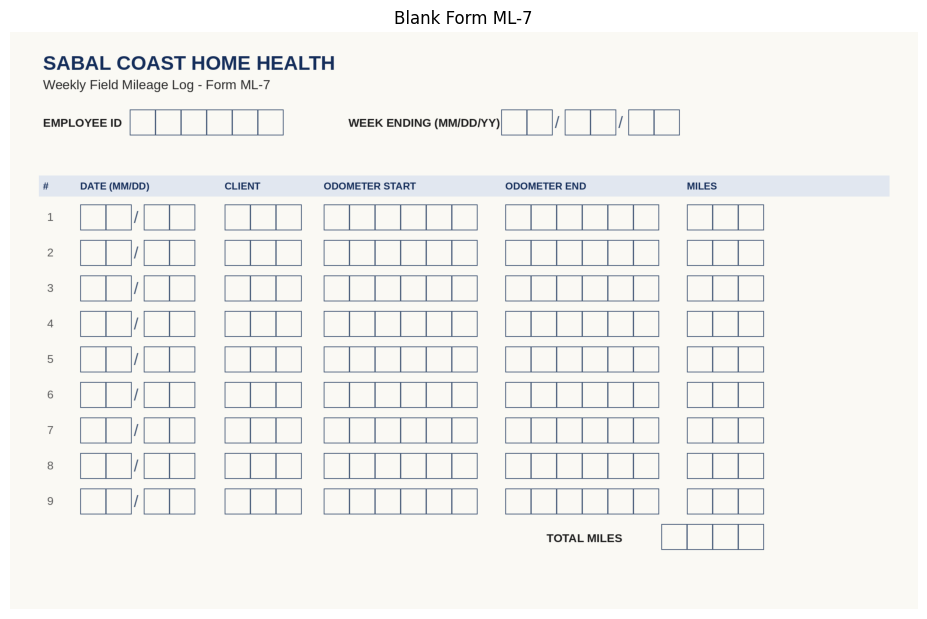

In [ ]:
template_gray = cv2.imread(str(ASSETS / 'blank_form_ML7.png'), cv2.IMREAD_GRAYSCALE)
blank_form = cv2.cvtColor(cv2.imread(str(ASSETS / 'blank_form_ML7.png')), cv2.COLOR_BGR2RGB)
fields = json.load(open(ASSETS / 'form_layout.json'))      # {field name: [box rectangles]}
FORM_H, FORM_W = template_gray.shape
print(f'Blank form {FORM_W} x {FORM_H} px, {len(fields)} fields, {sum(len(r) for r in fields.values())} boxes')
plt.figure(figsize=(12, 7.5)); plt.imshow(blank_form); plt.axis('off'); plt.title('Blank Form ML-7'); plt.show()

60 logs saved to /content/ML-for-NLP/data/synthetic_logs


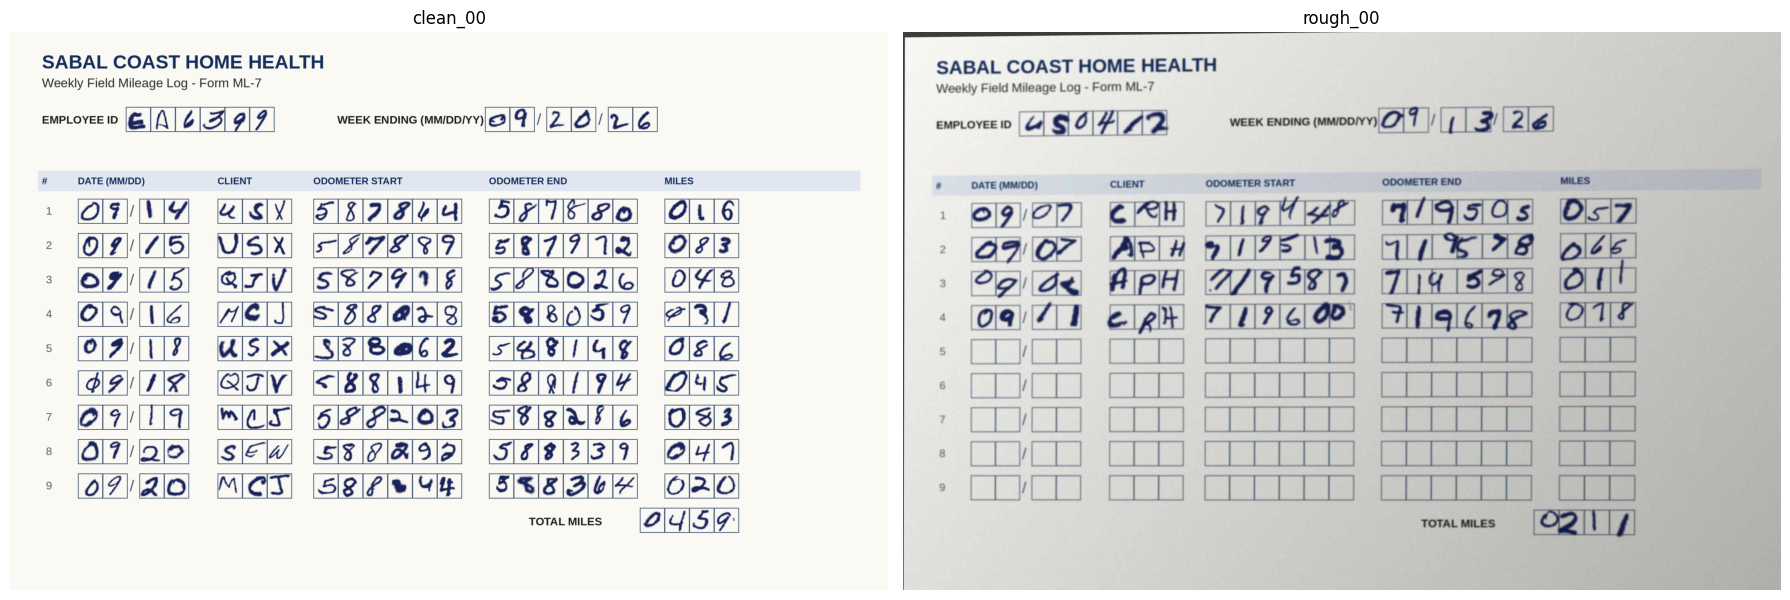

{'date': '0914', 'client': 'USX', 'odo_start': '587864', 'odo_end': '587880', 'miles': '016'}


In [ ]:
# Glyph bank: TEST split only (digits + capitals), so no training image ever appears in a test log
glyph_bank = {EMNIST_MAP[c]: x_test[y_test == c] for c in range(N_CLASSES)}

def write_field(ink, rects, text, rng, messy=0.0):
    """Place one EMNIST glyph per box. messy (0-1) increases size, tilt and position jitter."""
    for (x0, y0, x1, y1), ch in zip(rects, text):
        bank = glyph_bank[ch]
        g = bank[rng.integers(len(bank))].astype(np.float32) / 255.0
        size = int(BOX * rng.uniform(0.85, 1.0 + 0.25 * messy))
        g = cv2.resize(g, (size, size), interpolation=cv2.INTER_CUBIC)
        Mrot = cv2.getRotationMatrix2D((size / 2, size / 2), rng.normal(0, 4 + 6 * messy), 1.0)
        g = np.clip(cv2.warpAffine(g, Mrot, (size, size)), 0, 1)
        cx = (x0 + x1) / 2 + rng.normal(0, 2 + 7 * messy)
        cy = (y0 + y1) / 2 + rng.normal(0, 2 + 7 * messy)
        px, py = int(cx - size / 2), int(cy - size / 2)
        ys, xs = max(py, 0), max(px, 0)
        ye, xe = min(py + size, ink.shape[0]), min(px + size, ink.shape[1])
        ink[ys:ye, xs:xe] = np.maximum(ink[ys:ye, xs:xe], g[ys - py:ye - py, xs - px:xe - px])

def compose(paper_rgb, ink, ink_rgb=(25, 35, 90)):
    """Blend the ink layer onto the paper (EMNIST white-on-black becomes dark ink on light paper)."""
    paper = paper_rgb.astype(np.float32)
    a = np.clip(ink * 1.15, 0, 1)[..., None]
    return (paper * (1 - a) + np.array(ink_rgb, np.float32) * a).astype(np.uint8)

def degrade(img, rng, strength=1.0):
    """Make a clean page look like a phone photo: uneven light, blur, noise, skew, JPEG."""
    if strength <= 0:
        return img
    a = img.astype(np.float32)
    H, W = a.shape[:2]
    yy, xx = np.mgrid[0:H, 0:W]
    light = 1.0 - 0.20 * strength * (xx / W) - 0.10 * strength * (yy / H)
    a = a * light[..., None]
    a = cv2.GaussianBlur(a, (0, 0), 0.5 + 1.0 * strength)
    a = a + rng.normal(0, 6 * strength, a.shape)
    a = np.clip(a, 0, 255).astype(np.uint8)
    j = 0.015 * strength
    src = np.float32([[0, 0], [W, 0], [W, H], [0, H]])
    dst = (src + rng.uniform(-j, j, (4, 2)) * np.array([W, H])).astype(np.float32)
    a = cv2.warpPerspective(a, cv2.getPerspectiveTransform(src, dst), (W, H), borderValue=(60, 60, 60))
    _, enc = cv2.imencode('.jpg', a[..., ::-1], [cv2.IMWRITE_JPEG_QUALITY, int(90 - 45 * strength)])
    return cv2.imdecode(enc, 1)[..., ::-1]

LETTERS = list('ABCDEFGHIJKLMNOPQRSTUVWXYZ')

def random_log_data(rng, n_rows=None):
    """Valid log: Sunday week-ending, dates inside the week, odometers running forward, miles = end - start."""
    n_rows = n_rows or int(rng.integers(4, 10))
    emp = ''.join(rng.choice(LETTERS, 2)) + f'{rng.integers(0, 10000):04d}'
    week_end = dt.date(2026, 9, 6) + dt.timedelta(weeks=int(rng.integers(0, 8)))  # Sept 6, 2026 is a Sunday
    clients = [''.join(rng.choice(LETTERS, 3)) for _ in range(4)]
    odo = int(rng.integers(1000, 900000))
    rows = []
    for d in sorted(rng.integers(0, 7, n_rows)):
        date = week_end - dt.timedelta(days=int(6 - d))
        odo += int(rng.integers(0, 15))          # personal miles between trips
        miles = int(rng.integers(5, 100))
        rows.append({'date': date.strftime('%m%d'), 'client': str(rng.choice(clients)),
                     'odo_start': f'{odo:06d}', 'odo_end': f'{odo + miles:06d}', 'miles': f'{miles:03d}'})
        odo += miles
    total = sum(int(r['miles']) for r in rows)
    return {'emp_id': emp, 'week_ending': week_end.strftime('%m%d%y'),
            'rows': rows, 'total_miles': f'{total:04d}'}

def make_log(data, rng, messy=0.1, strength=0.0):
    ink = np.zeros((FORM_H, FORM_W), np.float32)
    write_field(ink, fields['emp_id'], data['emp_id'], rng, messy)
    write_field(ink, fields['week_ending'], data['week_ending'], rng, messy)
    for r, row in enumerate(data['rows']):
        for key in KEYS:
            write_field(ink, fields[f'r{r}_{key}'], row[key], rng, messy)
    write_field(ink, fields['total_miles'], data['total_miles'], rng, messy)
    return degrade(compose(blank_form, ink), rng, strength)

rng = np.random.default_rng(SYNTH_SEED)
order = list(CONDITIONS)
for cond, (messy, strength) in CONDITIONS.items():
    for i in range(N_PER_CONDITION):
        data = random_log_data(rng)
        img = make_log(data, rng, messy, strength)
        name = f'{cond}_{i:02d}'
        cv2.imwrite(str(SYNTH_DIR / f'{name}.png'), img[..., ::-1])
        json.dump({**data, 'condition': cond, 'messy': messy, 'degrade_strength': strength},
                  open(SYNTH_DIR / f'{name}.json', 'w'), indent=1)
print(f"{len(list(SYNTH_DIR.glob('*.png')))} logs saved to {SYNTH_DIR}")

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
for ax, name in zip(axes, ['clean_00', 'rough_00']):
    ax.imshow(cv2.imread(str(SYNTH_DIR / f'{name}.png'))[..., ::-1])
    ax.set_title(name); ax.axis('off')
plt.tight_layout(); plt.show()
print(json.load(open(SYNTH_DIR / 'clean_00.json'))['rows'][0])

## 3. Model: a small CNN, baseline and augmented

Conv(32) > ReLU > MaxPool > Conv(64) > ReLU > MaxPool > Linear(128) > ReLU > Dropout(0.3) > Linear(36) > log_softmax.
Adam, NLLLoss with class weights (letters are rarer than digits). Both models use the same settings; the augmented
one sees randomly tilted, shifted, scaled, thicker/thinner and blurred training images.

In [ ]:
class CharCNN(nn.Module):
    def __init__(self, n_classes=N_CLASSES):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)   # 1x28x28  -> 32x28x28
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)  # 32x14x14 -> 64x14x14
        self.pool = nn.MaxPool2d(2)                               # halves height and width
        self.dropout = nn.Dropout(0.3)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, n_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))      # -> 32x14x14
        x = self.pool(F.relu(self.conv2(x)))      # -> 64x7x7
        x = x.view(x.size(0), -1)                 # flatten
        x = self.dropout(F.relu(self.fc1(x)))
        return F.log_softmax(self.fc2(x), dim=1)

print(CharCNN())
print('Trainable parameters:', sum(p.numel() for p in CharCNN().parameters() if p.requires_grad))

# Class weights: rare classes (letters like Q, X, Z) count more in the loss,
# because client codes on the form use letters close to uniformly
counts = np.bincount(y_train, minlength=N_CLASSES)
class_weights = torch.tensor(counts.sum() / (N_CLASSES * counts), dtype=torch.float32).to(device)
criterion = nn.NLLLoss(weight=class_weights)

def evaluate(model, loader):
    model.to(device).eval()
    correct = total = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            correct += (model(x).argmax(dim=1) == y).sum().item()
            total += y.size(0)
    return correct / total

HISTORY = {}      # per-epoch loss and validation accuracy of every model trained in this session

def train(path, augment_fn=None):
    """Train a fresh CharCNN for EPOCHS epochs and keep the best validation epoch at `path`.
    Skipped when the weights already exist (unless RETRAIN = True)."""
    model = CharCNN().to(device)
    if path.exists() and not RETRAIN:
        print(f'Using existing weights: {path.name} (set RETRAIN = True to train again)')
        model.load_state_dict(torch.load(path, map_location=device))
        return model.eval()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    best_val = 0.0
    hist = {'loss': [], 'val_acc': []}
    for epoch in range(EPOCHS):
        model.train()
        running_loss = 0.0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            if augment_fn:
                x = augment_fn(x)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * y.size(0)
        val_acc = evaluate(model, val_loader)       # validation on normal (un-augmented) images
        hist['loss'].append(running_loss / len(train_ds)); hist['val_acc'].append(val_acc)
        print(f'Epoch {epoch + 1}/{EPOCHS} | train loss {running_loss / len(train_ds):.4f} | val acc {val_acc:.2%}')
        if val_acc > best_val:
            best_val = val_acc
            torch.save(model.state_dict(), path)
    HISTORY[path.name] = hist
    print(f'Best validation accuracy: {best_val:.2%} (saved to {path})')
    model.load_state_dict(torch.load(path, map_location=device))
    return model.eval()

model = train(SAVE_PATH)     # baseline

CharCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=36, bias=True)
)
Trainable parameters: 424996
Epoch 1/5 | train loss 0.4926 | val acc 89.63%
Epoch 2/5 | train loss 0.2832 | val acc 91.46%
Epoch 3/5 | train loss 0.2421 | val acc 90.96%
Epoch 4/5 | train loss 0.2189 | val acc 91.63%
Epoch 5/5 | train loss 0.2032 | val acc 91.55%
Best validation accuracy: 91.63% (saved to /content/ML-for-NLP/models/char_cnn_best.pt)


In [ ]:
def predict(model, x, allowed=None):
    """Returns (predicted class, confidence). allowed = class indices the field permits."""
    logp = model(x)
    if allowed is not None:
        mask = torch.full_like(logp, float('-inf'))
        mask[:, allowed] = 0
        logp = logp + mask
    probs = torch.softmax(logp, dim=1)    # renormalized over the allowed classes
    conf, pred = probs.max(dim=1)
    return pred, conf

def predict_all(model, allowed=None):
    model.to(device).eval()
    out = []
    with torch.no_grad():
        for x, _ in test_loader:
            out.append(predict(model, x.to(device), allowed)[0].cpu())
    return torch.cat(out).numpy()

free, as_digit, as_letter = predict_all(model), predict_all(model, DIGITS), predict_all(model, LETTERS_IDX)
is_digit = y_test < 10
print('Condition: isolated EMNIST test-split characters (clean, centered, no form), baseline model\n')
print(f"Digits,  free choice (36 classes):  {(free[is_digit] == y_test[is_digit]).mean():.2%}")
print(f"Digits,  restricted to 0-9:         {(as_digit[is_digit] == y_test[is_digit]).mean():.2%}")
print(f"Letters, free choice (36 classes):  {(free[~is_digit] == y_test[~is_digit]).mean():.2%}")
print(f"Letters, restricted to A-Z:         {(as_letter[~is_digit] == y_test[~is_digit]).mean():.2%}")
print(f"Overall, free choice:               {(free == y_test).mean():.2%}")

Condition: isolated EMNIST test-split characters (clean, centered, no form), baseline model

Digits,  free choice (36 classes):  92.74%
Digits,  restricted to 0-9:         99.28%
Letters, free choice (36 classes):  89.81%
Letters, restricted to A-Z:         97.81%
Overall, free choice:               91.71%


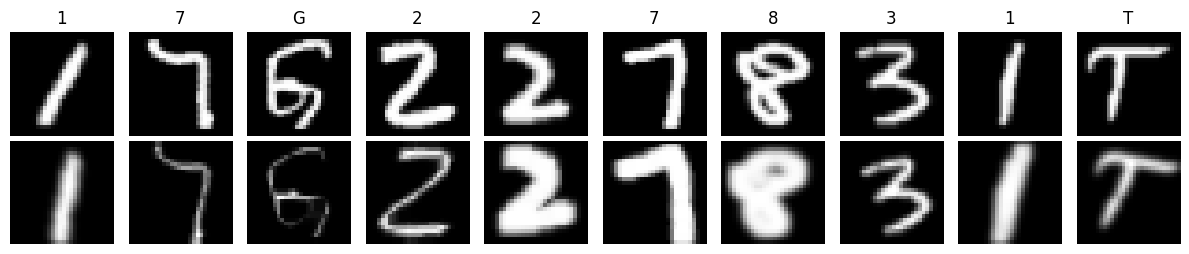

Epoch 1/5 | train loss 0.7725 | val acc 89.11%
Epoch 2/5 | train loss 0.4537 | val acc 88.98%
Epoch 3/5 | train loss 0.3943 | val acc 90.43%
Epoch 4/5 | train loss 0.3663 | val acc 90.49%
Epoch 5/5 | train loss 0.3458 | val acc 91.13%
Best validation accuracy: 91.13% (saved to /content/ML-for-NLP/models/char_cnn_aug_best.pt)


In [ ]:
def augment(x):
    """(B,1,28,28) in [-1,1] -> random tilt/shift/scale/shear, thicker or thinner strokes, blur."""
    B, dev = x.size(0), x.device
    x = (x + 1) / 2                                   # to [0,1] so empty padding stays black background
    ang = torch.empty(B, device=dev).uniform_(-12, 12) * math.pi / 180
    scale = torch.empty(B, device=dev).uniform_(0.85, 1.15)
    shear = torch.empty(B, device=dev).uniform_(-0.2, 0.2)
    tx = torch.empty(B, device=dev).uniform_(-0.12, 0.12)
    ty = torch.empty(B, device=dev).uniform_(-0.12, 0.12)
    cos, sin = torch.cos(ang) / scale, torch.sin(ang) / scale
    theta = torch.stack([torch.stack([cos, -sin + shear, tx], 1),
                         torch.stack([sin, cos, ty], 1)], 1)
    grid = F.affine_grid(theta, x.shape, align_corners=False)
    x = F.grid_sample(x, grid, padding_mode='zeros', align_corners=False)

    r = torch.rand(B, device=dev).view(B, 1, 1, 1)
    thick = F.max_pool2d(x, 3, stride=1, padding=1)      # dilate: thicker strokes
    thin = -F.max_pool2d(-x, 3, stride=1, padding=1)     # erode: thinner strokes (like a fine pen)
    x = torch.where(r < 0.3, thick, x)
    x = torch.where(r > 0.85, thin, x)

    k = torch.tensor([1., 2., 1.], device=dev)
    k = (k[:, None] * k[None, :] / 16).view(1, 1, 3, 3)
    blurred = F.conv2d(x, k, padding=1)
    x = torch.where(torch.rand(B, device=dev).view(B, 1, 1, 1) < 0.3, blurred, x)
    return x * 2 - 1

# Quick visual check: top = original, bottom = augmented
xb, yb = next(iter(train_loader))
xa = augment(xb[:10].to(device)).cpu()
fig, axes = plt.subplots(2, 10, figsize=(12, 2.6))
for i in range(10):
    axes[0, i].imshow(xb[i, 0], cmap='gray'); axes[0, i].set_title(EMNIST_MAP[yb[i]]); axes[0, i].axis('off')
    axes[1, i].imshow(xa[i, 0], cmap='gray'); axes[1, i].axis('off')
plt.tight_layout(); plt.show()

# Same model, loss, optimizer settings and epochs as the baseline -- only the training images differ
model_aug = train(AUG_PATH, augment_fn=augment)

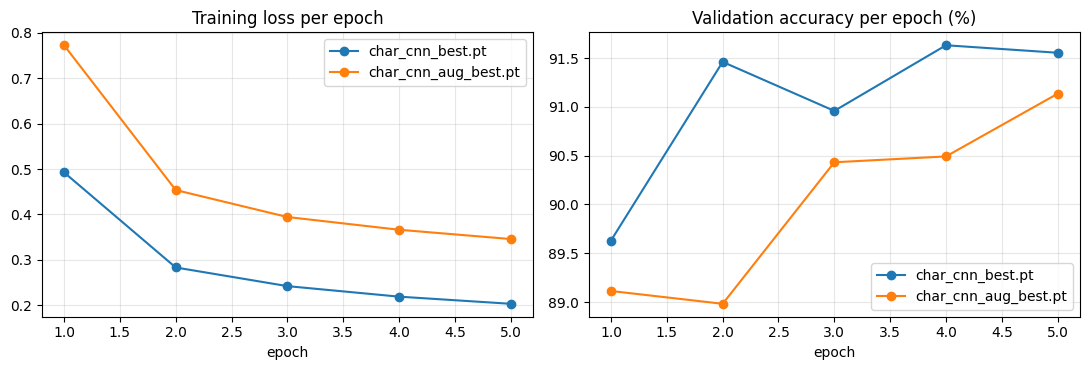

In [ ]:
# Training curves (only for models trained in this session; with RETRAIN = False the weights are loaded instead)
if not HISTORY:
    print('Nothing was trained in this session (RETRAIN = False), so there are no curves to draw.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
    for name, h in HISTORY.items():
        xs = range(1, len(h['loss']) + 1)
        axes[0].plot(xs, h['loss'], marker='o', label=name)
        axes[1].plot(xs, [100 * v for v in h['val_acc']], marker='o', label=name)
    axes[0].set_title('Training loss per epoch'); axes[1].set_title('Validation accuracy per epoch (%)')
    for ax in axes:
        ax.set_xlabel('epoch'); ax.grid(alpha=0.3); ax.legend()
    plt.tight_layout(); plt.show()

## 4. From photo to characters: registration, cell extraction, reading

1. **Registration:** match SIFT features between the photo and the blank form, then straighten the photo onto it.
2. **Cell extraction:** erase the printed box lines and cut out each box, keeping only ink strokes that reach the middle of the box.
3. **Normalization:** make every crop look like EMNIST (white on black, fit into 20x20, centered by center of mass in 28x28).
4. **Reading:** the CNN reads each box; digit boxes can only be 0-9, letter boxes only A-Z.

In [ ]:
sift = cv2.SIFT_create(nfeatures=5000)
tmpl_kp, tmpl_des = sift.detectAndCompute(template_gray, None)

def register_form(photo_bgr, min_inliers=40):
    """Straighten a photo of Form ML-7 onto the blank template (handles skew, rotation, scale)."""
    gray = cv2.cvtColor(photo_bgr, cv2.COLOR_BGR2GRAY)
    scale = 1.0
    if max(gray.shape) > 3000:                      # phone photos can be huge; shrink for speed
        scale = 3000 / max(gray.shape)
        gray = cv2.resize(gray, None, fx=scale, fy=scale, interpolation=cv2.INTER_AREA)
    kp, des = sift.detectAndCompute(gray, None)
    if des is None:
        raise ValueError('No features found in photo')
    matcher = cv2.BFMatcher(cv2.NORM_L2)
    good = [m for m, n in matcher.knnMatch(des, tmpl_des, k=2) if m.distance < 0.75 * n.distance]
    if len(good) < min_inliers:
        raise ValueError(f'Only {len(good)} feature matches -- is the whole form in the photo?')
    src = np.float32([kp[m.queryIdx].pt for m in good]) / scale
    dst = np.float32([tmpl_kp[m.trainIdx].pt for m in good])
    H, inlier_mask = cv2.findHomography(src, dst, cv2.RANSAC, 5.0)
    if H is None or int(inlier_mask.sum()) < min_inliers:
        raise ValueError('Registration failed -- photo too blurry, cropped, or not Form ML-7')
    h, w = template_gray.shape
    warped = cv2.warpPerspective(photo_bgr, H, (w, h), borderValue=(255, 255, 255))
    return warped, int(inlier_mask.sum())

def ink_map(warped_bgr):
    """Dark ink on light paper -> ink strength 0-1 (white on black), evening out shadows and uneven light."""
    gray = cv2.cvtColor(warped_bgr, cv2.COLOR_BGR2GRAY).astype(np.float32)
    background = cv2.medianBlur(gray.astype(np.uint8), 51).astype(np.float32)
    ink = np.clip(background - gray, 0, None)
    ink = np.clip(ink / max(np.percentile(ink, 99.9), 1.0), 0, 1)
    ink[ink < 0.15] = 0
    return ink

def erase_box_lines(ink, line_px=4):
    """We know exactly where the printed box lines are after registration, so blank them out."""
    out = ink.copy()
    for rects in fields.values():
        for x0, y0, x1, y1 in rects:
            out[y0 - line_px:y0 + line_px, x0 - line_px:x1 + line_px] = 0
            out[y1 - line_px:y1 + line_px, x0 - line_px:x1 + line_px] = 0
            out[y0 - line_px:y1 + line_px, x0 - line_px:x0 + line_px] = 0
            out[y0 - line_px:y1 + line_px, x1 - line_px:x1 + line_px] = 0
    return out

def to_emnist28(cell):
    """Same normalization as EMNIST: crop to ink, fit in 20x20, center by mass in 28x28, uint8 0-255."""
    ys, xs = np.nonzero(cell > 0.15)
    if len(ys) == 0:
        return np.zeros((28, 28), np.uint8)
    cell = cell[ys.min():ys.max() + 1, xs.min():xs.max() + 1]
    h, w = cell.shape
    s = 20.0 / max(h, w)
    cell = cv2.resize(cell, (max(1, round(w * s)), max(1, round(h * s))), interpolation=cv2.INTER_AREA)
    out = np.zeros((28, 28), np.float32)
    h, w = cell.shape
    y0, x0 = (28 - h) // 2, (28 - w) // 2
    out[y0:y0 + h, x0:x0 + w] = cell
    cy, cx = ndimage.center_of_mass(out)
    out = ndimage.shift(out, (14 - cy, 14 - cx), order=1)
    out = out / max(out.max(), 1e-6)
    return (np.clip(out, 0, 1) * 255).astype(np.uint8)

def extract_cells(photo_bgr, pad=6, min_ink=0.015):
    """Photo in -> {field name: [28x28 crop or None for an empty box]}."""
    warped, n_inliers = register_form(photo_bgr)
    ink = erase_box_lines(ink_map(warped))
    cells = {}
    for name, rects in fields.items():
        crops = []
        for x0, y0, x1, y1 in rects:
            region = ink[y0 - pad:y1 + pad, x0 - pad:x1 + pad]
            if (region > 0.3).mean() < min_ink:          # almost no ink -> empty box
                crops.append(None)
                continue
            # keep only ink strokes that reach the middle of the box (ignores spillover from neighbors)
            lab, _ = ndimage.label(region > 0.15)
            H_, W_ = region.shape
            ids = [i for i in np.unique(lab[H_ // 4:3 * H_ // 4, W_ // 4:3 * W_ // 4]) if i > 0]
            if not ids:
                crops.append(None)
                continue
            crops.append(to_emnist28(region * np.isin(lab, ids)))
        cells[name] = crops
    return cells, warped, n_inliers

def allowed_classes(field, i):
    """Which classes a box may contain, from the form rules."""
    base = field.split('_', 1)[1] if re.match(r'r\d_', field) else field
    if base == 'client':
        return LETTERS_IDX
    if base == 'emp_id':
        return LETTERS_IDX if i < 2 else DIGITS   # 2 letters + 4 digits
    return DIGITS                                  # dates, odometers, miles, total

def read_cells(m, cells):
    """Read every box with model m. {field: [crops]} -> {field: (text read, [confidence per box])}. Empty box = ' '."""
    m = m.to(cpu).eval()
    out = {}
    for field, crops in cells.items():
        chars, confs = [], []
        for i, crop in enumerate(crops):
            if crop is None:
                chars.append(' '); confs.append(None)
                continue
            with torch.no_grad():
                pred, conf = predict(m, to_model_input(crop[None]), allowed_classes(field, i))
            chars.append(EMNIST_MAP[pred.item()]); confs.append(conf.item())
        out[field] = (''.join(chars), confs)
    return out

Registration inliers: 161 | filled cells found: 104 (expected 104)


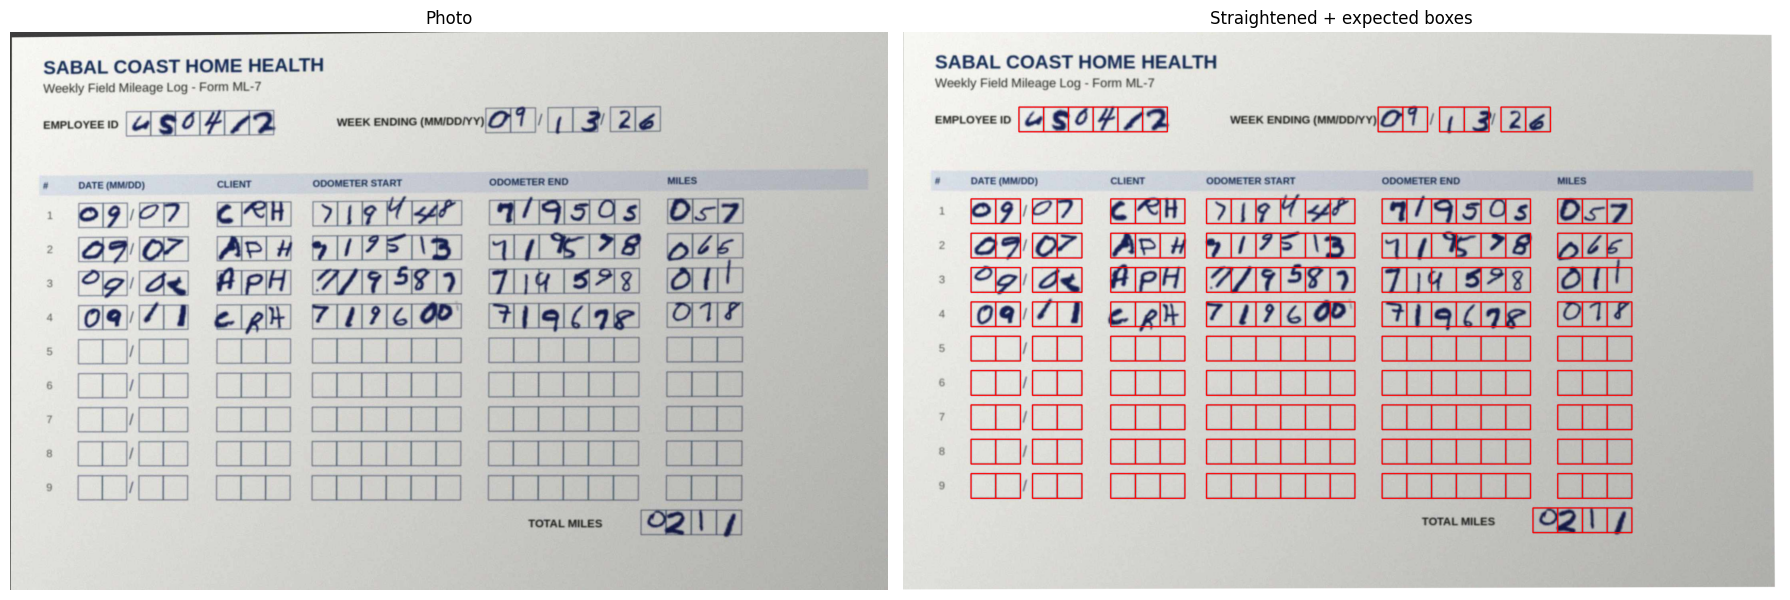

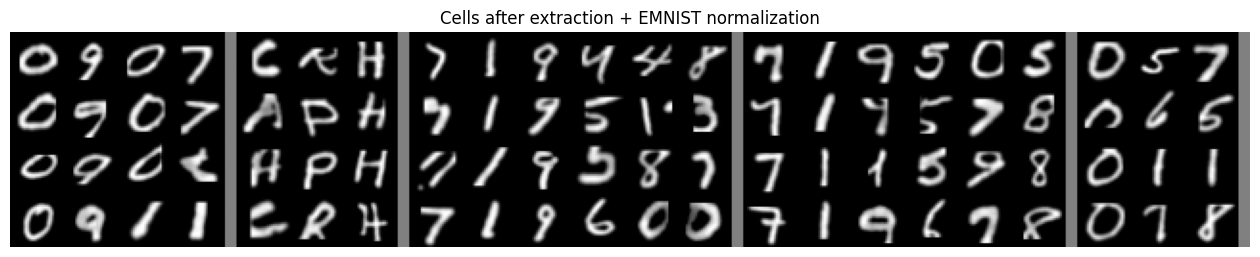

In [ ]:
# Example: one rough synthetic log, straightened, with the expected boxes drawn on it
photo = cv2.imread(str(SYNTH_DIR / 'rough_00.png'))
cells, warped, n_inliers = extract_cells(photo)
truth = json.load(open(SYNTH_DIR / 'rough_00.json'))
n_filled = sum(c is not None for crops in cells.values() for c in crops)
print(f"Registration inliers: {n_inliers} | filled cells found: {n_filled} (expected {12 + 22 * len(truth['rows']) + 4})")

overlay = warped.copy()
for rects in fields.values():
    for x0, y0, x1, y1 in rects:
        cv2.rectangle(overlay, (x0, y0), (x1, y1), (0, 0, 255), 2)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
axes[0].imshow(photo[..., ::-1]); axes[0].set_title('Photo')
axes[1].imshow(overlay[..., ::-1]); axes[1].set_title('Straightened + expected boxes')
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()

blank = np.full((28, 28), 80, np.uint8)
sep = np.full((28, 6), 128, np.uint8)
strips = []
for r in range(len(truth['rows'])):
    parts = []
    for key in KEYS:
        parts += [c if c is not None else blank for c in cells[f'r{r}_{key}']] + [sep]
    strips.append(np.hstack(parts))
plt.figure(figsize=(16, 0.8 * len(strips)))
plt.imshow(np.vstack(strips), cmap='gray'); plt.axis('off')
plt.title('Cells after extraction + EMNIST normalization'); plt.show()

In [ ]:
def truth_fields(t):
    f = {'emp_id': t['emp_id'], 'week_ending': t['week_ending'], 'total_miles': t['total_miles']}
    for r, row in enumerate(t['rows']):
        for key in KEYS:
            f[f'r{r}_{key}'] = row[key]
    return f

# Every synthetic log: cut the boxes once, read them with both models
models = {'baseline': model, 'augmented': model_aug}
logs, rows, reg_fail = {}, [], []
for path in sorted(SYNTH_DIR.glob('*.png')):
    truth_i = json.load(open(path.with_suffix('.json')))
    try:
        cells_i, _, _ = extract_cells(cv2.imread(str(path)))
    except ValueError:
        reg_fail.append(path.stem)
        continue
    gt_i = truth_fields(truth_i)
    for mname, m in models.items():
        reads_i = read_cells(m, cells_i)
        if mname == 'augmented':
            logs[path.stem] = (truth_i, reads_i)
        for field, true_text in gt_i.items():
            read_text = reads_i[field][0]
            pairs = list(zip(true_text, read_text))
            rows.append({'model': mname, 'condition': truth_i['condition'], 'log': path.stem, 'field': field,
                         'field_ok': read_text == true_text,
                         'missing': sum(c is None for c in cells_i[field]),
                         'digits': sum(t.isdigit() for t, _ in pairs),
                         'digits_ok': sum(t == r for t, r in pairs if t.isdigit()),
                         'letters': sum(not t.isdigit() for t, _ in pairs),
                         'letters_ok': sum(t == r for t, r in pairs if not t.isdigit())})
cmp = pd.DataFrame(rows)

def summarize(g):
    odo = g[g['field'].str.contains('odo')]
    return pd.Series({'digit acc': g.digits_ok.sum() / g.digits.sum(),
                      'letter acc': g.letters_ok.sum() / g.letters.sum(),
                      'field acc': g.field_ok.mean(),
                      'odo 6 of 6': (odo.digits_ok == 6).mean()})

table = pd.DataFrame({(c, mn): summarize(cmp[(cmp.condition == c) & (cmp.model == mn)])
                      for c in order for mn in models}).T
print(f'Registration: {60 - len(reg_fail)} of 60 logs registered', f'(failed: {reg_fail})' if reg_fail else '')
print(f"Boxes with handwriting that came out empty: {cmp[cmp.model == 'augmented'].missing.sum()}\n")
print('Synthetic Form ML-7 logs, 20 per condition, raw accuracy before any rules\n')
print(table.to_string(float_format='{:.1%}'.format))
cmp.to_csv(DATA / 'scorecard_baseline_vs_augmented.csv', index=False)

Registration: 60 of 60 logs registered 
Boxes with handwriting that came out empty: 2

Synthetic Form ML-7 logs, 20 per condition, raw accuracy before any rules

                 digit acc  letter acc  field acc  odo 6 of 6
clean baseline       98.2%       95.1%      90.4%       89.1%
      augmented      98.4%       97.2%      92.4%       91.1%
phone baseline       94.4%       87.0%      72.9%       66.4%
      augmented      96.6%       92.5%      83.3%       78.9%
rough baseline       88.6%       78.4%      55.1%       45.4%
      augmented      92.5%       83.7%      67.6%       63.8%


## 5. Business rules and the per-row decision

- Employee ID exists in the HR master list
- Week ending is a valid date, a Sunday, not in the future, and within the last 60 days
- Trip dates are valid and fall inside the week ending
- Client code is on the employee's visit schedule
- Miles = odometer end - start, and end is after start
- Odometer start is not before the previous row's end
- A trip over 300 miles is flagged as implausible
- Total miles = sum of the rows
- Any character with confidence below 0.50 is flagged

**Per-row policy:** a row is auto-posted only if none of its checks fail. A problem with the employee ID or week ending
sends the whole log to review. A wrong total is blamed on the rows already flagged; if no row is flagged, the whole log goes to review.

`reference_checks=False` is for a form whose employee is not in our made-up HR data: it skips the HR list, visit schedule
and 60-day checks; every other rule still runs.

In [ ]:
# Made-up reference data standing in for the HR system and the visit scheduler
_ref = json.load(open(ASSETS / 'reference_data.json'))
HR_MASTER = set(_ref['hr_master'])
VISIT_SCHEDULE = {emp: set(clients) for emp, clients in _ref['visit_schedule'].items()}
print('HR master list:', sorted(HR_MASTER))

def filled_rows(reads):
    return [r for r in range(9) if reads[f'r{r}_odo_start'][0].strip() or reads[f'r{r}_miles'][0].strip()]

def row_decisions(reads, issues):
    """Per-row decision: {row index: 'AUTO-POST' or 'REVIEW'}."""
    rows = filled_rows(reads)
    flagged = set()
    for i in issues:
        m = re.match(r'row (\d+):', i) or re.match(r'r(\d)_', i)
        if m:
            flagged.add(int(m.group(1)) - 1 if i.startswith('row ') else int(m.group(1)))
    log_level = [i for i in issues if not re.match(r'(row \d+:|r\d_)', i)]
    total_issue = any(i.startswith(('total miles', 'total_miles')) for i in log_level)
    header_issue = any(not i.startswith(('total miles', 'total_miles')) for i in log_level)
    if header_issue or (total_issue and not flagged):
        return {r: 'REVIEW' for r in rows}
    return {r: ('REVIEW' if r in flagged else 'AUTO-POST') for r in rows}

def validate(reads, as_of=None, reference_checks=True):
    """Check one log against the form's rules. Returns (decision, [reasons])."""
    as_of = as_of or dt.date.today()
    issues = []
    txt = lambda f: reads[f][0]

    emp = txt('emp_id')
    if reference_checks and emp not in HR_MASTER:
        issues.append(f"emp_id '{emp}' is not in the HR master list")

    try:
        we = dt.datetime.strptime(txt('week_ending'), '%m%d%y').date()
        if we.weekday() != 6:
            issues.append(f'week ending {we:%m/%d/%y} is not a Sunday')
        if we > as_of:
            issues.append(f'week ending {we:%m/%d/%y} is in the future')
        elif reference_checks and (as_of - we).days > MAX_AGE_DAYS:
            issues.append(f'week ending {we:%m/%d/%y} is more than {MAX_AGE_DAYS} days old')
    except ValueError:
        we = None
        issues.append(f"week ending '{txt('week_ending')}' is not a valid date")

    miles_sum, prev_end = 0, None
    for r in filled_rows(reads):
        tag = f'row {r + 1}'
        f = {k: txt(f'r{r}_{k}') for k in KEYS}
        empty = [k for k, v in f.items() if ' ' in v]
        if empty:
            issues.append(f'{tag}: empty box in {", ".join(empty)}')
        if reference_checks and emp in VISIT_SCHEDULE and ' ' not in f['client'] and f['client'] not in VISIT_SCHEDULE[emp]:
            issues.append(f"{tag}: client code '{f['client']}' is not on {emp}'s visit schedule")
        try:
            s, e, m = int(f['odo_start']), int(f['odo_end']), int(f['miles'])
        except ValueError:
            continue
        miles_sum += m
        if e <= s:
            issues.append(f'{tag}: odometer end {e} is not after start {s}')
        elif e - s != m:
            issues.append(f'{tag}: miles written {m} but end - start = {e - s}')
        elif m > MAX_TRIP_MILES:
            issues.append(f'{tag}: {m} miles is implausibly long for one trip')
        if prev_end is not None and s < prev_end:
            issues.append(f'{tag}: odometer start {s} is before the previous row end {prev_end}')
        prev_end = e
        if we:
            try:
                d = dt.date(we.year, int(f['date'][:2]), int(f['date'][2:]))
                if d > we:                                   # week crossing New Year
                    d = d.replace(year=we.year - 1)
                if not (we - dt.timedelta(days=6) <= d <= we):
                    issues.append(f'{tag}: date {d:%m/%d} is outside the week ending {we:%m/%d/%y}')
            except ValueError:
                issues.append(f"{tag}: date '{f['date']}' is not a valid date")

    try:
        total = int(txt('total_miles'))
        if total != miles_sum:
            issues.append(f'total miles {total} does not match the sum of rows {miles_sum}')
    except ValueError:
        issues.append(f"total miles '{txt('total_miles')}' is unreadable")

    for field, (text, confs) in reads.items():
        low = [c for c in confs if c is not None and c < CONF_MIN]
        if low:
            issues.append(f'{field}: low confidence ({min(low):.2f})')

    rd = row_decisions(reads, issues)
    n_post = sum(v == 'AUTO-POST' for v in rd.values())
    if rd and n_post == len(rd):
        decision = 'AUTO-POST'
    elif n_post == 0:
        decision = 'REVIEW'
    else:
        review = ', '.join(str(r + 1) for r, v in rd.items() if v == 'REVIEW')
        word = 'row' if len(rd) - n_post == 1 else 'rows'
        decision = f'{n_post} of {len(rd)} rows AUTO-POST, {len(rd) - n_post} to REVIEW ({word} {review})'
    return decision, issues

HR master list: ['AZ5783', 'LM2984', 'MT4826', 'RC5107', 'ZQ9081']


In [ ]:
# Synthetic logs: the generator invented these employees and clients, so here it plays the HR system
synth_hr = set(HR_MASTER)
synth_schedule = {k: set(v) for k, v in VISIT_SCHEDULE.items()}
for truth_i, _ in logs.values():
    synth_hr.add(truth_i['emp_id'])
    synth_schedule.setdefault(truth_i['emp_id'], set()).update(r['client'] for r in truth_i['rows'])

real_hr, real_schedule = HR_MASTER, VISIT_SCHEDULE
HR_MASTER, VISIT_SCHEDULE = synth_hr, synth_schedule
row_rows = []
for name, (truth_i, reads_i) in logs.items():
    gt_i = truth_fields(truth_i)
    _, issues = validate(reads_i, as_of=AS_OF_SYNTH)
    rd = row_decisions(reads_i, issues)
    header_ok = all(reads_i[f][0] == gt_i[f] for f in ['emp_id', 'week_ending'])
    for r in range(len(truth_i['rows'])):
        wrong = [k for k in KEYS if reads_i[f'r{r}_{k}'][0] != gt_i[f'r{r}_{k}']]
        row_rows.append({'log': name, 'condition': truth_i['condition'], 'row': r + 1,
                         'decision': rd.get(r, 'REVIEW'),
                         'row_correct': header_ok and not wrong,
                         'mileage_wrong': any(k.startswith(('odo', 'miles')) for k in wrong)})
HR_MASTER, VISIT_SCHEDULE = real_hr, real_schedule     # back to the real (made-up) HR data for the photos
rows_df = pd.DataFrame(row_rows)

def row_summary(g):
    posted = g[g.decision == 'AUTO-POST']
    return pd.Series({
        'rows': len(g),
        'auto-posted': len(posted),
        'straight-through rate': f'{len(posted) / len(g):.1%}',
        'auto-posted WITH an error': int((~posted.row_correct).sum()),
        'auto-posted WITH a mileage error': int(posted.mileage_wrong.sum()),
        'reviewed but actually correct': int(((g.decision == 'REVIEW') & g.row_correct).sum()),
    })

per_row_synth = pd.DataFrame({c: row_summary(g) for c, g in rows_df.groupby('condition')}).T.reindex(order)
print('Per-row decisions -- augmented model, 20 synthetic logs per condition\n')
print(per_row_synth.to_string())
rows_df.to_csv(DATA / 'decisions_per_row.csv', index=False)

Per-row decisions -- augmented model, 20 synthetic logs per condition

      rows auto-posted straight-through rate auto-posted WITH an error auto-posted WITH a mileage error reviewed but actually correct
clean  151          92                 60.9%                         3                                0                             8
phone  128          37                 28.9%                         0                                0                             3
rough  130          11                  8.5%                         0                                0                             1


## 6. Real handwriting: the four printed forms photographed with an iPhone

**What was written on each form** (ground truth). If you change a form, change it here.

In [ ]:
FORMS = {
    'ODO_1': {'photo': 'samples/ODO_1.heic', 'reference_checks': True,
              'emp_id': 'AZ5783', 'week_ending': '100426', 'total_miles': '0443',
              'rows': [('0928', 'KMR', '052310', '052347', '037'),
                       ('0928', 'PDL', '052347', '052398', '051'),
                       ('0929', 'AVT', '052405', '052462', '057'),
                       ('0929', 'KMR', '052462', '052490', '028'),
                       ('0930', 'JBS', '052496', '052569', '073'),
                       ('1001', 'PDL', '052575', '052611', '036'),
                       ('1001', 'WHC', '052611', '052655', '044'),
                       ('1002', 'AVT', '052660', '052729', '069'),
                       ('1003', 'KMR', '052733', '052781', '048')]},
    'ODO_2': {'photo': 'samples/ODO_2.heic', 'reference_checks': False,   # QS2047 is not in our HR data
              'emp_id': 'QS2047', 'week_ending': '091326', 'total_miles': '0411',   # written 0411; rows add to 476
              'rows': [('0907', 'OIS', '017420', '017469', '049'),
                       ('0907', 'BZQ', '017469', '017538', '069'),
                       ('0908', 'OIS', '017541', '017597', '056'),
                       ('0909', 'GSB', '017597', '017671', '074'),
                       ('0910', 'QOD', '017675', '017713', '038'),
                       ('0910', 'BZQ', '017713', '017757', '044'),
                       ('0911', 'QOD', '017760', '017838', '078'),
                       ('0912', 'GSB', '017843', '017884', '041'),
                       ('0913', 'OIS', '017886', '017913', '027')]},
    'ODO_3': {'photo': 'samples/ODO_3.heic', 'reference_checks': True,
              'emp_id': 'MT4826', 'week_ending': '092026', 'total_miles': '0337',
              'rows': [('0914', 'GEN', '099671', '099706', '035'),
                       ('0914', 'SOL', '099706', '099711', '005'),
                       ('0915', 'TRB', '099718', '099783', '065'),
                       ('0915', 'MXQ', '099783', '099831', '048'),
                       ('0916', 'SOL', '099837', '099846', '009'),
                       ('0917', 'GEN', '099846', '099898', '052'),
                       ('0917', 'TRB', '099902', '099959', '057'),
                       ('0918', 'SOL', '099959', '099964', '005'),
                       ('0919', 'MXQ', '099972', '100033', '061')]},
    'ODO_4': {'photo': 'samples/ODO_4.heic', 'reference_checks': True,
              'emp_id': 'AZ5783', 'week_ending': '092726', 'total_miles': '0455',
              'rows': [('0921', 'KMR', '051790', '051846', '056'),
                       ('0921', 'PDL', '051846', '051875', '029'),
                       ('0922', 'AVT', '051881', '051965', '084'),
                       ('0923', 'JBS', '051965', '052008', '043'),
                       ('0929', 'WHC', '052012', '052077', '065'),   # written 09/29: outside the week ending 09/27
                       ('0924', 'KMR', '052077', '052114', '037'),
                       ('0925', 'PDL', '052119', '052191', '072'),
                       ('0926', 'AVT', '052191', '052209', '018'),
                       ('0927', 'JBS', '052212', '052263', '051')]},
}

In [ ]:
def load_photo(path):
    """JPG, PNG or iPhone HEIC -> OpenCV (BGR) image the right way up."""
    img = ImageOps.exif_transpose(Image.open(path)).convert('RGB')
    return np.array(img)[..., ::-1].copy()

def failed_chars(reads, issues):
    """Which characters each failed rule points to: {field: set of positions}. Where a rule can point to
    the likely wrong character (client code one letter off a scheduled code, impossible month or day digit),
    only that character is marked; otherwise the whole field is."""
    out = {}
    def mark(name, pos=None):
        out.setdefault(name, set()).update(range(len(reads[name][0])) if pos is None else pos)
    for i in issues:
        m = re.match(r'row (\d+): (.*)', i)
        if not m:
            for name in ('emp_id', 'week_ending', 'total_miles'):
                if i.startswith((name, name.replace('_', ' '))):
                    mark(name)
            continue
        r, msg = int(m.group(1)) - 1, m.group(2)
        if msg.startswith('client code'):
            read = reads[f'r{r}_client'][0]
            diffs = [[k for k, (a, b) in enumerate(zip(read, code)) if a != b]
                     for code in VISIT_SCHEDULE.get(reads['emp_id'][0], ())]
            best = min(map(len, diffs), default=0)
            closest = [d for d in diffs if len(d) == best]
            mark(f'r{r}_client', closest[0] if len(closest) == 1 and best < len(read) else None)
        elif msg.startswith('date'):
            d = reads[f'r{r}_date'][0]
            mm, dd = d[:2], d[2:]
            if not (mm.isdigit() and 1 <= int(mm) <= 12):
                mark(f'r{r}_date', [0] if mm[0] > '1' else [1])
            elif not (dd.isdigit() and 1 <= int(dd) <= 31):
                mark(f'r{r}_date', [2] if dd[0] > '3' else [3])
            else:
                mark(f'r{r}_date')
        elif msg.startswith(('miles written', 'odometer end')):
            for k in ('odo_start', 'odo_end', 'miles'):
                mark(f'r{r}_{k}')
        elif msg.startswith('odometer start'):
            mark(f'r{r}_odo_start')
        elif 'implausibly long' in msg:
            mark(f'r{r}_miles')
        elif msg.startswith('empty box in'):
            for k in msg[len('empty box in'):].split(','):
                mark(f'r{r}_{k.strip()}')
    return out

### Reading with runner-up guesses, and rule-guided auto-correct

The model's top guess is kept, together with its next two guesses. After the rules run, two things can happen to **mileage
digits only** (dates and client codes are never changed):

1. **Confirm:** a digit the model was unsure of (below 0.50) is accepted when end - start = miles agrees, because that
   arithmetic would not work out by accident.
2. **Swap:** when a row fails, one digit is replaced by the model's 2nd or 3rd guess, but only if it is the *only* single
   swap that makes the row pass every rule and it creates no new problem in any other row.

Anything ambiguous stays in REVIEW. Changed digits get **blue** boxes. Set `AUTO_CORRECT = False` to turn this off.

In [ ]:
# ---------- 1. Read every box, keeping the runner-up guesses too ----------
def predict_top3(m, x, allowed=None):
    """Like predict(), but returns the top 3 guesses as [(class, probability), ...]."""
    logp = m(x)
    if allowed is not None:
        mask = torch.full_like(logp, float('-inf'))
        mask[:, allowed] = 0
        logp = logp + mask
    probs = torch.softmax(logp, dim=1)
    p, idx = probs.topk(3, dim=1)
    return [(idx[0, j].item(), p[0, j].item()) for j in range(3)]

def read_cells_alt(m, cells):
    """Same as read_cells, plus the runner-up guesses for every box.
    Returns reads {field: (text, [confidence per box])} and
    alts {field: [[(2nd guess char, prob), (3rd guess char, prob)] or None]}."""
    m = m.to(cpu).eval()
    reads, alts = {}, {}
    for field, crops in cells.items():
        chars, confs, alt = [], [], []
        for i, crop in enumerate(crops):
            if crop is None:
                chars.append(' '); confs.append(None); alt.append(None)
                continue
            with torch.no_grad():
                top = predict_top3(m, to_model_input(crop[None]), allowed_classes(field, i))
            chars.append(EMNIST_MAP[top[0][0]]); confs.append(top[0][1])
            alt.append([(EMNIST_MAP[c], p) for c, p in top[1:]])
        reads[field] = (''.join(chars), confs)
        alts[field] = alt
    return reads, alts

# ---------- 2. Auto-correct / confirm uncertain mileage digits, only when the form's own rules agree ----------
def row_issue_map(issues):
    """{row index: [issues that belong to that row]}"""
    out = {}
    for i in issues:
        m = re.match(r'row (\d+):', i)
        if m:
            out.setdefault(int(m.group(1)) - 1, []).append(i)
            continue
        m = re.match(r'r(\d)_', i)
        if m:
            out.setdefault(int(m.group(1)), []).append(i)
    return out

def only_low_conf_mileage(row_issues, r):
    """True if every problem in this row is a low-confidence flag on a mileage box (no rule failed)."""
    pat = re.compile(rf"r{r}_({'|'.join(AUTO_CORRECT_FIELDS)}): low confidence")
    return bool(row_issues) and all(pat.match(i) for i in row_issues)

def auto_correct(reads, alts, reference_checks=True, as_of=None):
    """Two things, both only on mileage boxes and only when the form's own rules agree:
    1. SWAP: for a row with a problem, try replacing ONE character by the model's 2nd or 3rd guess. Applied only if it is
       the ONLY single swap that makes the row pass, and it creates no new problem in any other row.
    2. CONFIRM: a character the model was unsure of (below CONF_MIN) is accepted when end - start = miles and the
       other rules pass, because that arithmetic would not work out by accident.
    Anything ambiguous stays in REVIEW. Returns (reads after the changes, list of corrections)."""
    reads = {f: (t, list(c)) for f, (t, c) in reads.items()}
    corrections = []
    check = lambda rd: row_issue_map(validate(rd, as_of=as_of, reference_checks=reference_checks)[1])

    def confirm_row(r, row_issues):
        for k in AUTO_CORRECT_FIELDS:
            field = f'r{r}_{k}'
            text, confs = reads[field]
            for pos, c in enumerate(confs):
                if c is not None and c < CONF_MIN:
                    corrections.append({'row': r, 'field': field, 'pos': pos, 'from': text[pos], 'to': text[pos],
                                        'old_conf': c, 'alt_prob': c, 'kind': 'confirmed'})
                    confs[pos] = 1.0

    for r in filled_rows(reads):
        before = check(reads)
        if not before.get(r):
            continue                                   # row already passes: leave it alone
        if CONFIRM_LOW_CONF and only_low_conf_mileage(before[r], r):
            confirm_row(r, before[r])
            continue
        winners = []
        for k in AUTO_CORRECT_FIELDS:
            field = f'r{r}_{k}'
            text, confs = reads[field]
            for pos, cands in enumerate(alts[field]):
                for ch, prob in (cands or []):
                    if prob < ALT_MIN_PROB:
                        continue
                    t_confs = list(confs); t_confs[pos] = 1.0      # rule-confirmed
                    trial = dict(reads)
                    trial[field] = (text[:pos] + ch + text[pos + 1:], t_confs)
                    after = check(trial)
                    worse = any(len(v) > len(before.get(o, [])) for o, v in after.items() if o != r)
                    passes = not after.get(r) or (CONFIRM_LOW_CONF and only_low_conf_mileage(after[r], r))
                    if passes and not worse:
                        winners.append((field, pos, ch, prob, trial[field]))
        if len(winners) == 1:
            field, pos, ch, prob, new_val = winners[0]
            corrections.append({'row': r, 'field': field, 'pos': pos, 'from': reads[field][0][pos], 'to': ch,
                                'old_conf': reads[field][1][pos], 'alt_prob': prob, 'kind': 'swap'})
            reads[field] = new_val
            if CONFIRM_LOW_CONF and check(reads).get(r):
                confirm_row(r, None)                   # the rest of the row is only unsure digits the arithmetic now confirms
    return reads, corrections

# ---------- 3. Run one photo ----------
def run_photo(path, reference_checks=True, as_of=None):
    """Photo -> straighten, cut boxes, read, auto-correct close calls, check the rules."""
    t0 = time.time()
    cells, warped, n_inl = extract_cells(load_photo(path))
    reads_raw, alts = read_cells_alt(model_aug, cells)
    reads, corrections = (auto_correct(reads_raw, alts, reference_checks, as_of)
                          if AUTO_CORRECT else (reads_raw, []))
    decision, issues = validate(reads, as_of=as_of, reference_checks=reference_checks)
    conf_show = {f: list(c) for f, (t, c) in reads_raw.items()}      # honest confidences for display
    for c in corrections:
        conf_show[c['field']][c['pos']] = c['alt_prob']      # swap: probability of the char now used; confirmed: original confidence
    return {'cells': cells, 'reads': reads, 'reads_raw': reads_raw, 'alts': alts, 'corrections': corrections,
            'conf_show': conf_show, 'issues': issues, 'decision': decision,
            'per_row': row_decisions(reads, issues), 'warped': warped, 'inliers': n_inl,
            'reference_checks': reference_checks, 'seconds': time.time() - t0}

# ---------- 4. Show the result ----------
def pretty(field):
    m = re.match(r'r(\d)_(.+)', field)
    return f"row {int(m.group(1)) + 1} {m.group(2).replace('_', ' ')}" if m else field.replace('_', ' ')

def show_result(name, res, save=False):
    """Each read above its box, the decision at the end of each row.
    red = low confidence, orange = confident read but fails a rule, green = OK, blue = auto-corrected by the rules."""
    img = res['warped'].copy()
    failed = failed_chars(res['reads'], res['issues'])
    fixed = {(c['field'], c['pos']) for c in res['corrections']}
    for field, rects in fields.items():
        text, _ = res['reads'][field]
        confs = res['conf_show'][field]
        for k, ((x0, y0, x1, y1), ch, conf) in enumerate(zip(rects, text, confs)):
            if conf is None:
                continue
            if (field, k) in fixed:
                color = (255, 90, 0)                                   # blue (OpenCV colors are BGR)
            elif conf < CONF_MIN:
                color = (0, 0, 255)                                    # red
            elif k in failed.get(field, ()):
                color = (0, 140, 255)                                  # orange
            else:
                color = (0, 160, 0)                                    # green
            cv2.rectangle(img, (x0, y0), (x1, y1), color, 2)
            cv2.putText(img, ch, (x0 + 4, y0 - 4), cv2.FONT_HERSHEY_SIMPLEX, 0.9, color, 2)
    for r, d in res['per_row'].items():
        x1, y0 = fields[f'r{r}_miles'][-1][2], fields[f'r{r}_miles'][-1][1]
        cv2.putText(img, d, (x1 + 20, y0 + 42), cv2.FONT_HERSHEY_SIMPLEX, 1.0,
                    (0, 160, 0) if d == 'AUTO-POST' else (0, 0, 255), 2)
    if save:
        cv2.imwrite(str(ROOT / f'result_{name.lower()}.png'), img)
    plt.figure(figsize=(16, 10)); plt.imshow(img[..., ::-1]); plt.axis('off')
    plt.title(f"{name}: {res['decision']}\n(red = low confidence, orange = fails a rule, green = OK, blue = auto-corrected)")
    plt.show()

def print_reads(res):
    reads, cs = res['reads'], res['conf_show']
    fmt = lambda c: ' n/a' if c is None else f'{c:.2f}'
    lowest = lambda fs: min([c for f in fs for c in cs[f] if c is not None], default=None)
    print(f"Employee ID: {reads['emp_id'][0]} (lowest confidence {fmt(lowest(['emp_id']))})    "
          f"Week ending: {reads['week_ending'][0]} (lowest confidence {fmt(lowest(['week_ending']))})")
    print(f"{res['inliers']} feature matches, read in {res['seconds']:.1f} s\n")
    print(f"{'row':<5}{'date':<7}{'client':<8}{'odo start':<11}{'odo end':<11}{'miles':<7}{'min conf':<10}decision")
    for r, d in res['per_row'].items():
        g = lambda k: reads[f'r{r}_{k}'][0]
        row_min = lowest([f'r{r}_{k}' for k in KEYS])
        print(f"{r + 1:<5}{g('date'):<7}{g('client'):<8}{g('odo_start'):<11}{g('odo_end'):<11}{g('miles'):<7}{fmt(row_min):<10}{d}")
    print(f"\nTotal miles: {reads['total_miles'][0]} (lowest confidence {fmt(lowest(['total_miles']))})")

    # the characters the model was least sure about, with its runner-up guess
    fixed = {(c['field'], c['pos']): c for c in res['corrections']}
    calls = []
    for field, (text, confs) in res['reads_raw'].items():
        for pos, (ch, c) in enumerate(zip(text, confs)):
            if c is not None and (c < 0.90 or (field, pos) in fixed):
                calls.append((c, field, pos, ch))
    if calls:
        print('\nClose calls (confidence below 0.90):')
        for c, field, pos, ch in sorted(calls)[:10]:
            alt = ', '.join(f"'{a}' ({p:.2f})" for a, p in res['alts'][field][pos])
            fx = fixed.get((field, pos))
            extra = ('' if fx is None else "  -> confirmed by the rules" if fx['kind'] == 'confirmed'
                     else f"  -> auto-corrected to '{fx['to']}'")
            print(f"  {pretty(field)}, char {pos + 1}: read '{ch}' ({c:.2f}), next guesses {alt}{extra}")

    if res['corrections']:
        print('\nChanged or confirmed by the rules (blue boxes):')
        for c in res['corrections']:
            if c['kind'] == 'confirmed':
                print(f"  - {pretty(c['field'])}, char {c['pos'] + 1}: '{c['from']}' kept (read at {c['old_conf']:.2f}); end - start = miles agrees")
            else:
                print(f"  - {pretty(c['field'])}, char {c['pos'] + 1}: '{c['from']}' -> '{c['to']}' (only swap that makes the row pass every rule)")
    print(f"\nDecision: {res['decision']}")
    for i in res['issues']:
        print('  -', i)
    if not res['reference_checks']:
        print('  (HR list, visit schedule and 60-day checks were skipped)')

In [ ]:
def truth_to_fields(t):
    f = {'emp_id': t['emp_id'], 'week_ending': t['week_ending'], 'total_miles': t['total_miles']}
    for r, row in enumerate(t['rows']):
        f.update({f'r{r}_{k}': v for k, v in zip(KEYS, row)})
    return f

def pretty(field):
    m = re.match(r'r(\d)_(.+)', field)
    return f"row {int(m.group(1)) + 1} {m.group(2).replace('_', ' ')}" if m else field.replace('_', ' ')

def score_form(name, res):
    """Compare what was written with what was read: characters, fields, and what happened to every row."""
    t = FORMS[name]
    gt = truth_to_fields(t)
    reads, per_row, issues = res['reads'], res['per_row'], res['issues']     # reads = after rule-guided changes
    raw = res['reads_raw']                                                     # raw = what the model read, before any change
    # Run the rules on what was WRITTEN: anything they flag is a mistake on the paper, not a misread
    written = {f: (v, [1.0] * len(v)) for f, v in gt.items()}
    _, written_issues = validate(written, reference_checks=t['reference_checks'])
    form_mistake_rows = {r for r, d in row_decisions(written, written_issues).items() if d == 'REVIEW'}
    if len(form_mistake_rows) == len(t['rows']):      # header or total mistake on paper: no single row to blame
        form_mistake_rows = set()

    errors, score = [], {'digit': [0, 0], 'letter': [0, 0]}
    for field, w in gt.items():
        rd = raw[field][0]
        for a, b in zip(w, rd):
            kind = 'digit' if a.isdigit() else 'letter'
            score[kind][1] += 1
            score[kind][0] += a == b
        if rd != w:
            m = re.match(r'r(\d)_', field)
            if m:
                caught = per_row.get(int(m.group(1))) == 'REVIEW'
            else:
                caught = any(field in i or field.replace('_', ' ') in i for i in issues)
            kinds = sorted({'digit' if a.isdigit() else 'letter' for a, b in zip(w, rd) if a != b})
            errors.append({'field': pretty(field), 'written': w, 'read': rd,
                           'wrong': sum(a != b for a, b in zip(w, rd)), 'kind': '+'.join(kinds),
                           'flagged by a rule?': 'fixed by rules' if reads[field][0] == w else ('yes' if caught else 'NO')})

    header_ok = all(reads[f][0] == gt[f] for f in ['emp_id', 'week_ending'])
    outcome = []
    for r in range(len(t['rows'])):
        row_ok = header_ok and all(reads[f'r{r}_{k}'][0] == gt[f'r{r}_{k}'] for k in KEYS)
        d = per_row.get(r, 'REVIEW')
        if d == 'AUTO-POST':
            outcome.append('auto-posted, correct' if row_ok else 'AUTO-POSTED WITH AN ERROR')
        elif r in form_mistake_rows:
            outcome.append('review: mistake on the form')
        elif not row_ok:
            outcome.append('review: misread caught')
        else:
            outcome.append('review: read correctly (flagged by a neighbor row or the total)')
    return {'errors': errors, 'score': score, 'outcome': outcome,
            'fields_ok': sum(raw[f][0] == v for f, v in gt.items()), 'fields': len(gt),
            'written_issues': written_issues}

def print_form_summary(name, res, s):
    """The per-form summary: what was written vs what was read, and the decision."""
    print(f"Photo: {FORMS[name]['photo']}  |  Form {name}  |  Condition: real handwriting, printed form, phone photo\n")
    if s['errors']:
        print(pd.DataFrame(s['errors']).to_string(index=False))
    else:
        print('No errors: every box was read correctly.')
    d, l = s['score']['digit'], s['score']['letter']
    print(f"\nCharacters: {d[0] + l[0]}/{d[1] + l[1]} = {(d[0] + l[0]) / (d[1] + l[1]):.1%}")
    print(f"Digits:     {d[0]}/{d[1]} = {d[0] / d[1]:.1%}")
    print(f"Letters:    {l[0]}/{l[1]} = {l[0] / l[1]:.1%}")
    print(f"Fields fully correct: {s['fields_ok']}/{s['fields']}")
    print(f"\nDecision: {res['decision']}")
    for i in res['issues']:
        print('  -', i)
    missed = [e for e in s['errors'] if e['flagged by a rule?'] == 'NO']
    if missed:
        print(f"\nErrors NOT flagged by any rule: {len(missed)} ({', '.join(e['field'] for e in missed)})")
    if s['written_issues']:
        print('\nMistakes on the paper itself (flagged even with a perfect read):')
        for i in s['written_issues']:
            print('  -', i)

### Each form: what the model read, the picture, and the summary

Character and field accuracy below are the **model's raw reads**. Rows, decisions and the picture use the reads after the
rule-guided changes (blue boxes). Forms whose photo is not in the repo are skipped.

In [ ]:
results, scores = {}, {}
for name, t in FORMS.items():
    print('=' * 110, f'\n{name}\n')
    photo = ROOT / t['photo']
    if not photo.exists():
        print(f"{t['photo']} is not in the repo, skipped (use the upload section at the end instead)\n")
        continue
    res = run_photo(photo, reference_checks=t['reference_checks'])
    results[name], scores[name] = res, score_form(name, res)
    print_reads(res)
    show_result(name, res)
    print_form_summary(name, res, scores[name])

ODO_1

samples/ODO_1.heic is not in the repo, skipped (use the upload section at the end instead)

ODO_2

samples/ODO_2.heic is not in the repo, skipped (use the upload section at the end instead)

ODO_3

samples/ODO_3.heic is not in the repo, skipped (use the upload section at the end instead)

ODO_4

samples/ODO_4.heic is not in the repo, skipped (use the upload section at the end instead)



### Summary of results: all four forms

In [ ]:
if not scores:
    print('No sample forms were found in samples/, so there is nothing to summarize. Use the upload section below.')
else:
    summary = []
    for name, s in scores.items():
        d, l = s['score']['digit'], s['score']['letter']
        out = pd.Series(s['outcome']).value_counts()
        summary.append({'form': name,
                        'characters': f"{d[0] + l[0]}/{d[1] + l[1]}",
                        'char acc': (d[0] + l[0]) / (d[1] + l[1]),
                        'digit acc': d[0] / d[1], 'letter acc': l[0] / l[1],
                        'fields fully correct': f"{s['fields_ok']}/{s['fields']}",
                        'rows': len(s['outcome']),
                        'auto-posted': int(sum(o.startswith('auto-posted') for o in s['outcome'])),
                        'auto-posted WITH an error': int(out.get('AUTO-POSTED WITH AN ERROR', 0)),
                        'review: misread caught': int(out.get('review: misread caught', 0)),
                        'review: mistake on the form': int(out.get('review: mistake on the form', 0)),
                        'review: read correctly': int(out.get('review: read correctly (flagged by a neighbor row or the total)', 0))})
    summary = pd.DataFrame(summary).set_index('form')

    tot_d = [sum(s['score']['digit'][i] for s in scores.values()) for i in (0, 1)]
    tot_l = [sum(s['score']['letter'][i] for s in scores.values()) for i in (0, 1)]
    total = {'characters': f"{tot_d[0] + tot_l[0]}/{tot_d[1] + tot_l[1]}",
             'char acc': (tot_d[0] + tot_l[0]) / (tot_d[1] + tot_l[1]),
             'digit acc': tot_d[0] / tot_d[1], 'letter acc': tot_l[0] / tot_l[1],
             'fields fully correct': f"{sum(s['fields_ok'] for s in scores.values())}/{sum(s['fields'] for s in scores.values())}"}
    total.update({c: int(summary[c].sum()) for c in summary.columns if summary[c].dtype.kind == 'i'})
    summary.loc['ALL 4'] = total
    n_rows, n_post = total['rows'], total['auto-posted']

    print('Condition: real handwriting, printed Form ML-7, iPhone photo, augmented model\n')
    print(summary.to_string(formatters={c: '{:.1%}'.format for c in ['char acc', 'digit acc', 'letter acc']}))
    print(f"\nStraight-through rate: {n_post}/{n_rows} rows = {n_post / n_rows:.1%}")
    print(f"Rows auto-posted with an error: {total['auto-posted WITH an error']}")

    errs = pd.DataFrame([{'form': n, **e} for n, s in scores.items() for e in s['errors']])
    print('\nEvery misread, and whether a rule caught it:\n')
    print(errs.to_string(index=False) if len(errs) else 'No misreads.')
    missed = errs[errs['flagged by a rule?'] == 'NO'] if len(errs) else errs
    print(f"\nMisreads NOT caught by any rule: {len(missed)}")

No sample forms were found in samples/, so there is nothing to summarize. Use the upload section below.


## 7. Try your own photos

Run the next cell, click **Choose files** and pick **one or several** photos of a filled-in Form ML-7 (JPG, PNG or iPhone HEIC).
Each photo prints its reads with the confidence of every row, the close calls, the rules that failed and the colored picture.

- If the file is named like one of the forms above (for example `ODO_3.heic`), the HR checks follow that form's setting
  and the photo is also compared with what was written.
- For any other photo, set `REFERENCE_CHECKS = False` if the employee is not in our made-up HR data.
- `AS_OF` is the date used for the "within the last 60 days" rule (None = today).

Saving ODO_1.heic to ODO_1.heic
Saving ODO_2.heic to ODO_2.heic
Saving ODO_4.heic to ODO_4.heic
Saving ODO_3.heic to ODO_3.heic
ODO_1.heic  

Employee ID: AZ5783 (lowest confidence 0.98)    Week ending: 100426 (lowest confidence 0.98)
108 feature matches, read in 2.3 s

row  date   client  odo start  odo end    miles  min conf  decision
1    0928   KMR     052310     052347     037    0.89      AUTO-POST
2    0928   DDL     052347     052398     051    0.98      REVIEW
3    0929   AVT     052405     052462     057    0.99      AUTO-POST
4    0929   UHR     052462     052490     028    0.60      REVIEW
5    0930   SBS     052496     052569     073    0.50      REVIEW
6    1001   PDL     052575     052611     036    0.76      AUTO-POST
7    1001   WHC     052611     052655     044    0.99      AUTO-POST
8    1002   AVT     052660     052729     069    0.91      AUTO-POST
9    1003   LMR     052733     052781     048    0.47      REVIEW

Total miles: 0443 (lowest confidence 1.00)

Close c

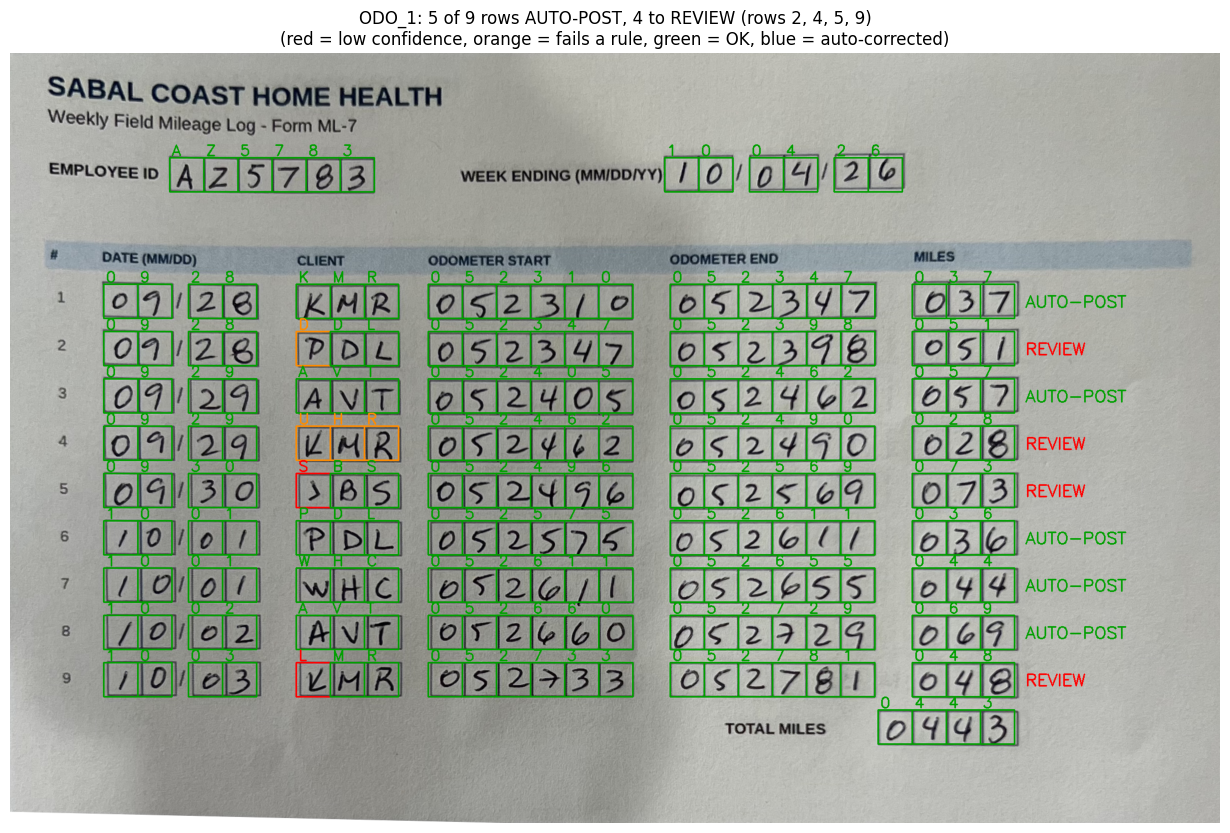

Photo: samples/ODO_1.heic  |  Form ODO_1  |  Condition: real handwriting, printed form, phone photo

       field written read  wrong   kind flagged by a rule?
row 2 client     PDL  DDL      1 letter                yes
row 4 client     KMR  UHR      2 letter                yes
row 5 client     JBS  SBS      1 letter                yes
row 9 client     KMR  LMR      1 letter                yes

Characters: 209/214 = 97.7%
Digits:     185/185 = 100.0%
Letters:    24/29 = 82.8%
Fields fully correct: 44/48

Decision: 5 of 9 rows AUTO-POST, 4 to REVIEW (rows 2, 4, 5, 9)
  - row 2: client code 'DDL' is not on AZ5783's visit schedule
  - row 4: client code 'UHR' is not on AZ5783's visit schedule
  - row 5: client code 'SBS' is not on AZ5783's visit schedule
  - row 9: client code 'LMR' is not on AZ5783's visit schedule
  - r4_client: low confidence (0.50)
  - r8_client: low confidence (0.47)
ODO_2.heic   (reference checks OFF) 

Employee ID: QS2047 (lowest confidence 0.99)    Week ending: 091

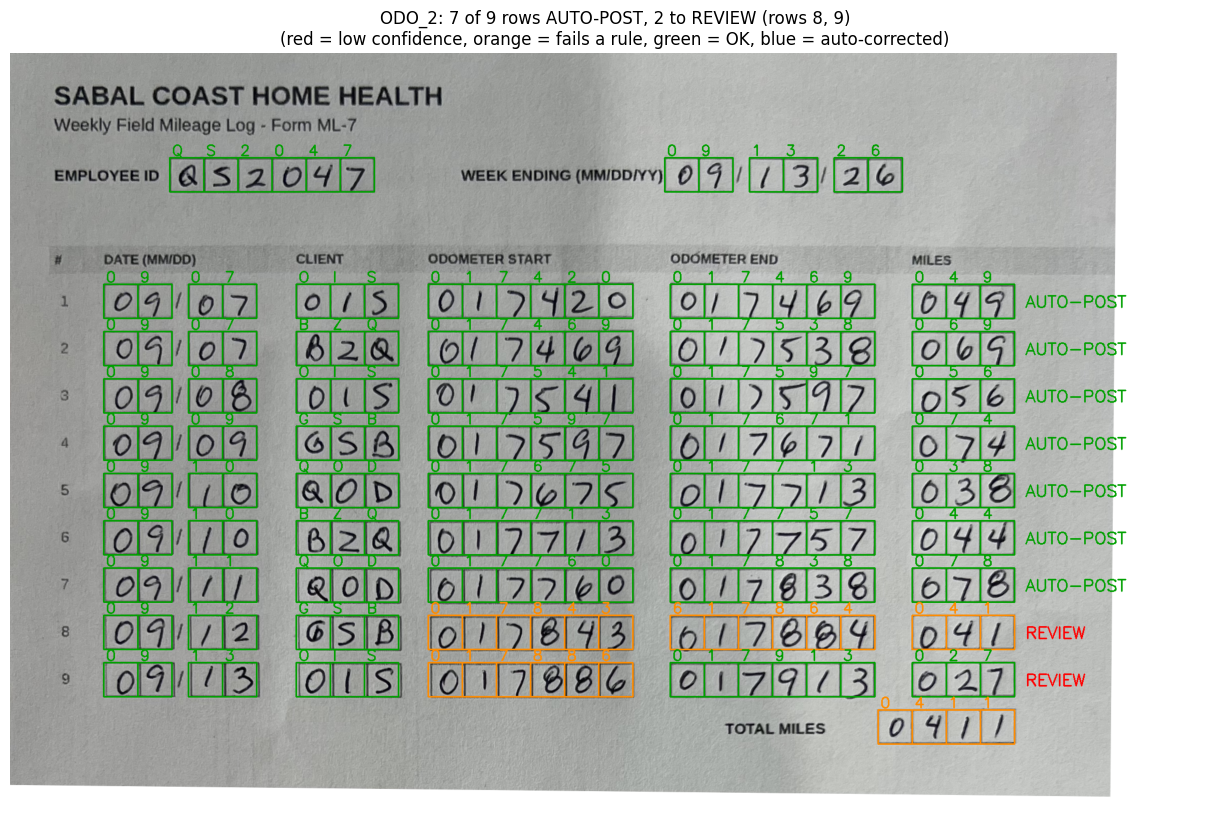

Photo: samples/ODO_2.heic  |  Form ODO_2  |  Condition: real handwriting, printed form, phone photo

        field written   read  wrong  kind flagged by a rule?
row 8 odo end  017884 617864      2 digit                yes

Characters: 212/214 = 99.1%
Digits:     183/185 = 98.9%
Letters:    29/29 = 100.0%
Fields fully correct: 47/48

Decision: 7 of 9 rows AUTO-POST, 2 to REVIEW (rows 8, 9)
  - row 8: miles written 41 but end - start = 600021
  - row 9: odometer start 17886 is before the previous row end 617864
  - total miles 411 does not match the sum of rows 476

Mistakes on the paper itself (flagged even with a perfect read):
  - total miles 411 does not match the sum of rows 476
ODO_4.heic  

Employee ID: AZ5783 (lowest confidence 0.98)    Week ending: 092726 (lowest confidence 0.83)
181 feature matches, read in 2.1 s

row  date   client  odo start  odo end    miles  min conf  decision
1    0921   KMR     051790     051846     056    0.56      AUTO-POST
2    0921   PDL     051846  

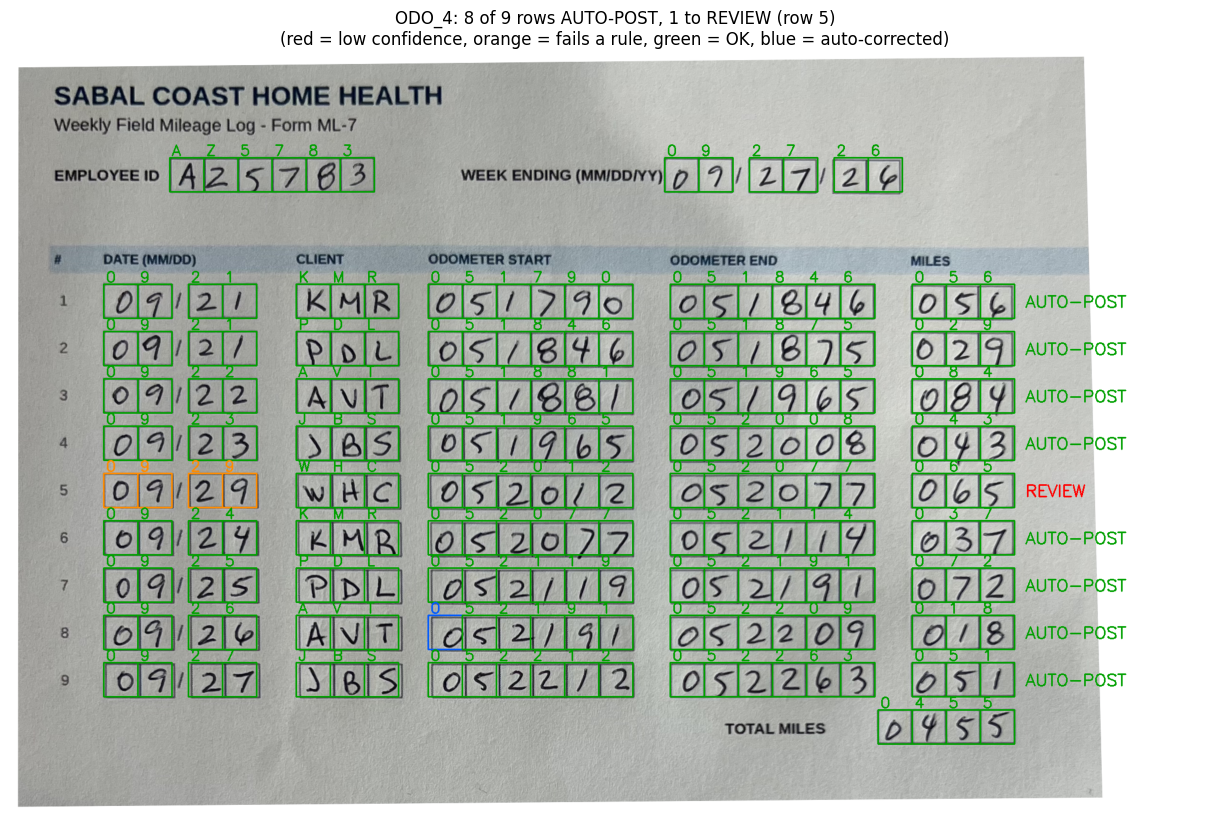

Photo: samples/ODO_4.heic  |  Form ODO_4  |  Condition: real handwriting, printed form, phone photo

          field written   read  wrong  kind flagged by a rule?
row 8 odo start  052191 652191      1 digit     fixed by rules

Characters: 213/214 = 99.5%
Digits:     184/185 = 99.5%
Letters:    29/29 = 100.0%
Fields fully correct: 47/48

Decision: 8 of 9 rows AUTO-POST, 1 to REVIEW (row 5)
  - row 5: date 09/29 is outside the week ending 09/27/26

Mistakes on the paper itself (flagged even with a perfect read):
  - row 5: date 09/29 is outside the week ending 09/27/26
ODO_3.heic  

Employee ID: MT4826 (lowest confidence 0.99)    Week ending: 092026 (lowest confidence 1.00)
116 feature matches, read in 2.1 s

row  date   client  odo start  odo end    miles  min conf  decision
1    0914   GEN     099671     099706     035    0.92      AUTO-POST
2    0914   SOL     099706     099711     005    0.99      AUTO-POST
3    0915   TRB     099718     099783     065    0.92      AUTO-POST
4    09

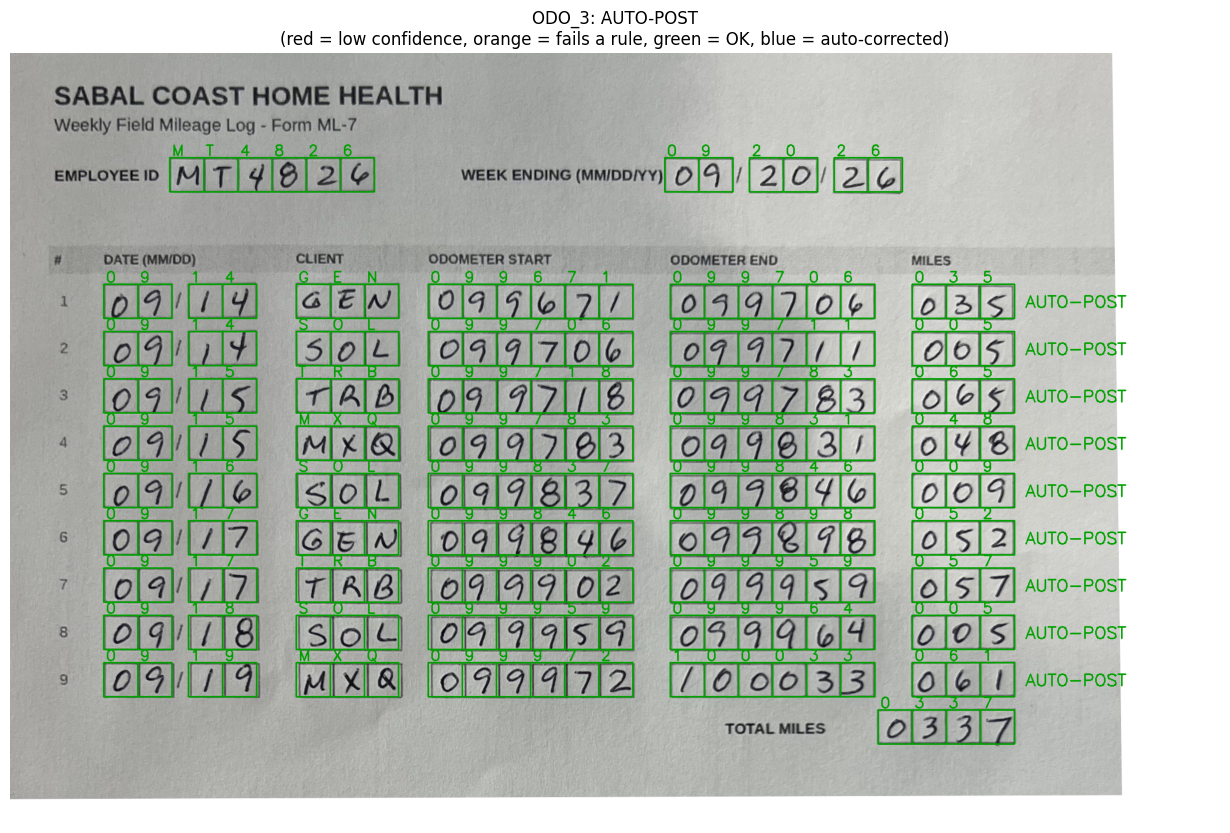

Photo: samples/ODO_3.heic  |  Form ODO_3  |  Condition: real handwriting, printed form, phone photo

No errors: every box was read correctly.

Characters: 214/214 = 100.0%
Digits:     185/185 = 100.0%
Letters:    29/29 = 100.0%
Fields fully correct: 48/48

Decision: AUTO-POST


In [ ]:
results, scores = globals().get('results', {}), globals().get('scores', {})
REFERENCE_CHECKS = True    # for photos that are not one of the four forms above
AS_OF = None               # None = today. To pretend it is another day: AS_OF = dt.date(2026, 10, 12)
SHOW_CROPS = False         # True = also draw the 28x28 crops the model saw, row by row

uploaded = files.upload()  # pick ONE or SEVERAL photos at once

for name, data in uploaded.items():
    path = UPLOAD_DIR / name
    path.write_bytes(data)
    key = re.match(r'(ODO_\d)', path.stem.upper())
    key = key.group(1) if key and key.group(1) in FORMS else None
    ref = FORMS[key]['reference_checks'] if key else REFERENCE_CHECKS
    print('=' * 110)
    print(name, '' if ref else '  (reference checks OFF)', '\n')
    try:
        res = run_photo(path, reference_checks=ref, as_of=AS_OF)
    except Exception as e:                      # one bad photo must not stop the others
        print('Could not read this photo:', e)
        print('Retake it with the whole form visible, flat, in good light.\n')
        continue
    print_reads(res)
    show_result(path.stem, res)
    if SHOW_CROPS:
        for r in res['per_row']:
            crops, labels = [], []
            for k in KEYS:
                text, _ = res['reads'][f'r{r}_{k}']
                for cr, ch in zip(res['cells'][f'r{r}_{k}'], text):
                    crops.append(cr if cr is not None else np.full((28, 28), 80, np.uint8))
                    labels.append(ch)
            fig, axes = plt.subplots(1, len(crops), figsize=(len(crops) * 0.6, 1))
            for ax, cr, ch in zip(axes, crops, labels):
                ax.imshow(cr, cmap='gray'); ax.set_title(ch, fontsize=9); ax.axis('off')
            fig.suptitle(f'Row {r + 1}', x=0.02, ha='left', fontsize=9)
            plt.show()
    if key:
        results[key], scores[key] = res, score_form(key, res)
        print_form_summary(key, res, scores[key])

## Keep the trained weights (optional)

Colab deletes its files when the session ends. Run this cell to download the two weight files, then upload them to the
`models/` folder of your GitHub repo if you want to reuse them later with `RETRAIN = False`.

In [ ]:
zip_path = shutil.make_archive('/content/models_trained', 'zip', MODELS)
files.download(zip_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>